<a href="https://colab.research.google.com/github/Abinaya21007/Image-Based-Breed-Recognition-for-Cattle-Buffalo-and-Sheep-in-India/blob/main/notebooks/swintransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm -q
print('Libraries ready!')

Libraries ready!


In [ ]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

print('All imports done!')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

All imports done!
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
zip_path     = '/content/drive/MyDrive/sheep_folder_swintransformer/augmented_dataset.zip'
extract_path = '/content/sheep_raw'

print('Unzipping...')
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
print('Unzip complete!')

# Auto detect folder
subfolders = [f for f in os.listdir(extract_path)
              if os.path.isdir(os.path.join(extract_path, f))]
print('Found folders:', subfolders)

dataset_root = extract_path
if len(subfolders) == 1:
    dataset_root = os.path.join(extract_path, subfolders[0])

breeds = sorted([d for d in os.listdir(dataset_root)
                 if os.path.isdir(os.path.join(dataset_root, d))])
print(f'Breeds found ({len(breeds)}): {breeds}')

Mounted at /content/drive
Unzipping...
Unzip complete!
Found folders: ['augmented_dataset']
Breeds found (7): ['Barbari', 'Goat', 'Harri', 'Naeimi', 'Najdi', 'Roman', 'Sawakni']


In [ ]:
split_root = '/content/sheep_split'

for split in ['train', 'val', 'test']:
    for breed in breeds:
        os.makedirs(os.path.join(split_root, split, breed), exist_ok=True)

for breed in breeds:
    breed_path = os.path.join(dataset_root, breed)
    images = [f for f in os.listdir(breed_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)

    splits = {
        'train': images[:n_train],
        'val'  : images[n_train:n_train + n_val],
        'test' : images[n_train + n_val:]
    }

    for split_name, imgs in splits.items():
        for img in imgs:
            shutil.copy2(os.path.join(breed_path, img),
                         os.path.join(split_root, split_name, breed, img))

    print(f'{breed}: Train={len(splits["train"])} | Val={len(splits["val"])} | Test={len(splits["test"])}')

print('Dataset split done!')

Barbari: Train=220 | Val=47 | Test=48
Goat: Train=219 | Val=47 | Test=48
Harri: Train=217 | Val=46 | Test=48
Naeimi: Train=220 | Val=47 | Test=48
Najdi: Train=215 | Val=46 | Test=47
Roman: Train=219 | Val=47 | Test=48
Sawakni: Train=219 | Val=47 | Test=48
Dataset split done!


In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(os.path.join(split_root, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(split_root, 'val'),   transform=val_test_transform)
test_ds  = datasets.ImageFolder(os.path.join(split_root, 'test'),  transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

NUM_CLASSES = len(train_ds.classes)
CLASS_NAMES = train_ds.classes

print(f'Breeds : {NUM_CLASSES}')
print(f'Names  : {CLASS_NAMES}')
print(f'Train  : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Breeds : 7
Names  : ['Barbari', 'Goat', 'Harri', 'Naeimi', 'Najdi', 'Roman', 'Sawakni']
Train  : 1529 | Val: 327 | Test: 335


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x))
        mx  = self.fc(self.max_pool(x))
        return self.sigmoid(avg + mx) * x


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg    = torch.mean(x, dim=1, keepdim=True)
        mx, _  = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

print('CBAM ready!')

CBAM ready!


In [ ]:
class SwinWithIntermediateCBAM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        # CBAM inserted between stages — NOVEL!
        self.cbam1 = CBAM(96)
        self.cbam2 = CBAM(192)
        self.cbam3 = CBAM(384)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(0.3),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def apply_cbam(self, x, cbam, H, W):
        # Handle any shape safely
        if x.dim() == 4:
            # Already (B, C, H, W)
            x = cbam(x)
        elif x.dim() == 3:
            # (B, L, C) → (B, C, H, W)
            B, L, C = x.shape
            x = x.permute(0, 2, 1).reshape(B, C, H, W)
            x = cbam(x)
            x = x.reshape(B, C, H * W).permute(0, 2, 1)
        return x

    def forward(self, x):
        # Check actual output shapes from swin layers
        x = self.swin.patch_embed(x)

        for i, layer in enumerate(self.swin.layers):
            x = layer(x)

            # Dynamically detect shape
            if x.dim() == 3:
                B, L, C = x.shape
                H = W = int(L ** 0.5)
            elif x.dim() == 4:
                B, H, W, C = x.shape
                # Convert to (B, C, H, W) for CBAM
                x = x.permute(0, 3, 1, 2)
                if i == 0:
                    x = self.cbam1(x)
                elif i == 1:
                    x = self.cbam2(x)
                elif i == 2:
                    x = self.cbam3(x)
                # Convert back to (B, H, W, C)
                x = x.permute(0, 2, 3, 1)
                continue

            # 3D case
            if i == 0:
                x = self.apply_cbam(x, self.cbam1, H, W)
            elif i == 1:
                x = self.apply_cbam(x, self.cbam2, H, W)
            elif i == 2:
                x = self.apply_cbam(x, self.cbam3, H, W)

        # Final norm
        x = self.swin.norm(x)

        # Handle output shape for head
        if x.dim() == 4:
            B, H, W, C = x.shape
            x = x.reshape(B, H*W, C)

        x = x.permute(0, 2, 1)  # (B, C, L)
        return self.head(x)


model = SwinWithIntermediateCBAM(num_classes=NUM_CLASSES).to(device)
print('Model ready!')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model ready!
Parameters: 27,744,039


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
print('Optimizer ready!')

In [ ]:
EPOCHS = 50
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = model(images).max(1)
        total   += labels.size(0)
        correct += pred.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            v_loss += criterion(out, labels).item()
            _, pred = out.max(1)
            v_total   += labels.size(0)
            v_correct += pred.eq(labels).sum().item()

    val_loss = v_loss / len(val_loader)
    val_acc  = 100. * v_correct / v_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%')

print(f'Best Val Accuracy: {best_val_acc:.2f}%')

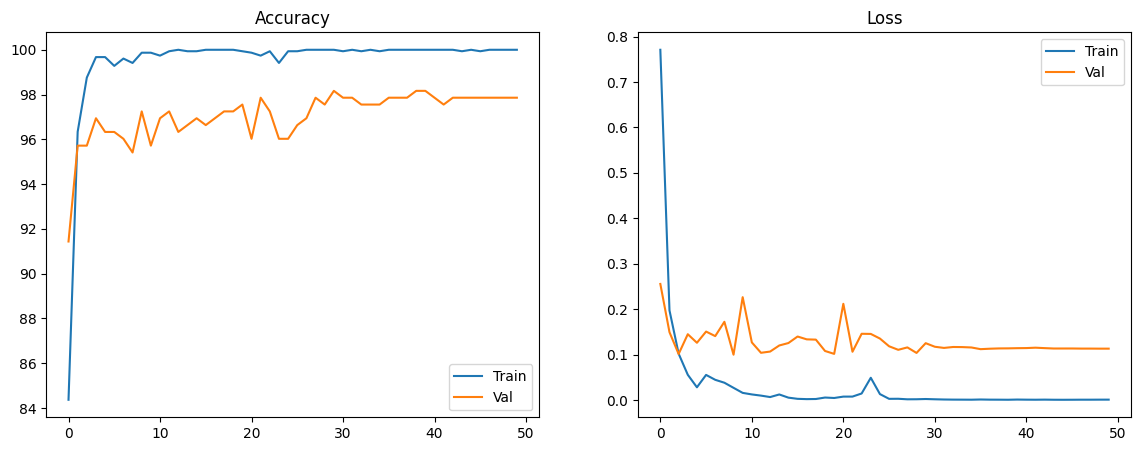

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_accs, label='Train')
axes[0].plot(val_accs,   label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(train_losses, label='Train')
axes[1].plot(val_losses,   label='Val')
axes[1].set_title('Loss')
axes[1].legend()
plt.savefig('graphs.png')
plt.show()

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        _, pred = model(images.to(device)).max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = 100. * sum(p==l for p,l in zip(all_preds,all_labels)) / len(all_labels)
print(f'Test Accuracy: {test_acc:.2f}%')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
# Google Drive-ல save பண்ணு
import shutil
save_path = '/content/drive/MyDrive/sheep_folder_swintransformer/best_model.pth'
shutil.copy('best_model.pth', save_path)
print(f'✅ Model saved to Drive: {save_path}')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import timm
import os

folder_path = '/content/drive/MyDrive/sheep_folder_swintransformer'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ Step 1: Checkpoint keys inspect pannu
model_path = os.path.join(folder_path, 'best_model.pth')
checkpoint = torch.load(model_path, map_location=device)
print("🔍 All keys in checkpoint:")
for k, v in checkpoint.items():
    print(f"  {k}: {v.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 All keys in checkpoint:
  swin.patch_embed.proj.weight: torch.Size([96, 3, 4, 4])
  swin.patch_embed.proj.bias: torch.Size([96])
  swin.patch_embed.norm.weight: torch.Size([96])
  swin.patch_embed.norm.bias: torch.Size([96])
  swin.layers.0.blocks.0.norm1.weight: torch.Size([96])
  swin.layers.0.blocks.0.norm1.bias: torch.Size([96])
  swin.layers.0.blocks.0.attn.relative_position_bias_table: torch.Size([169, 3])
  swin.layers.0.blocks.0.attn.qkv.weight: torch.Size([288, 96])
  swin.layers.0.blocks.0.attn.qkv.bias: torch.Size([288])
  swin.layers.0.blocks.0.attn.proj.weight: torch.Size([96, 96])
  swin.layers.0.blocks.0.attn.proj.bias: torch.Size([96])
  swin.layers.0.blocks.0.norm2.weight: torch.Size([96])
  swin.layers.0.blocks.0.norm2.bias: torch.Size([96])
  swin.layers.0.blocks.0.mlp.fc1.weight: torch.Size([384, 96])
  swin.layers.0.blocks.0.mlp.fc1.bia

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import timm
import os

folder_path = '/content/drive/MyDrive/sheep_folder_swintransformer'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('🖥️ Device:', device)

# ============================================================
# ✅ SHEEP MODEL - CBAM
# ============================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
    def forward(self, x):
        avg = x.mean(dim=[2,3], keepdim=True)
        max_ = x.amax(dim=[2,3], keepdim=True)
        att = torch.sigmoid(self.fc(avg) + self.fc(max_))
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_ = x.amax(dim=1, keepdim=True)
        att = torch.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))
        return x * att

class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels)
        self.spatial_att = SpatialAttention()
    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

class SwinClassifier(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.swin = timm.create_model('swin_tiny_patch4_window7_224',
                                       pretrained=False,
                                       num_classes=0,
                                       global_pool='')
        self.cbam1 = CBAM(96)
        self.cbam2 = CBAM(192)
        self.cbam3 = CBAM(384)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),    # 0
            nn.Flatten(),               # 1
            nn.LayerNorm(768),          # 2 ✅
            nn.GELU(),                  # 3
            nn.Linear(768, 256),        # 4 ✅
            nn.ReLU(),                  # 5
            nn.Dropout(0.3),            # 6
            nn.Linear(256, num_classes) # 7 ✅
        )
    def forward(self, x):
        x = self.swin(x)
        x = x.transpose(1, 2)
        return self.head(x)

# ============================================================
# ✅ COW MODEL
# ============================================================
class CowCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(192, 12, bias=False),  # 1 ✅
            nn.ReLU(),
            nn.Linear(12, 192, bias=False),  # 3 ✅
            nn.Sigmoid()
        )
        self.sp_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg = x.mean(dim=[2,3])
        att = self.mlp(avg).unsqueeze(-1).unsqueeze(-1)
        x = x * att
        sp_avg = x.mean(dim=1, keepdim=True)
        sp_max = x.amax(dim=1, keepdim=True)
        sp_att = torch.sigmoid(self.sp_conv(torch.cat([sp_avg, sp_max], dim=1)))
        return x * sp_att

class CowClassifier(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.swin = timm.create_model('swin_tiny_patch4_window7_224',
                                       pretrained=False,
                                       num_classes=0,
                                       global_pool='')
        self.cbam = CowCBAM()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),     # 0
            nn.LayerNorm(768),           # 1 ✅
            nn.Flatten(),                # 2
            nn.Linear(768, 512),         # 3 ✅
            nn.ReLU(),                   # 4
            nn.Dropout(0.3),             # 5
            nn.Linear(512, num_classes)  # 6 ✅
        )
    def forward(self, x):
        x = self.swin(x)
        x = x.transpose(1, 2)
        return self.head(x)

# ============================================================
# ✅ LOAD BOTH MODELS
# ============================================================
model = SwinClassifier(num_classes=7)
checkpoint = torch.load(os.path.join(folder_path, 'best_model.pth'), map_location=device)
model.load_state_dict(checkpoint)
model = model.to(device)
model.eval()
print("✅ Sheep Model loaded!")

cow_model = CowClassifier(num_classes=11)
cow_ckpt = torch.load(os.path.join(folder_path, 'best_cow_model.pth'), map_location=device)
cow_model.load_state_dict(cow_ckpt)
cow_model = cow_model.to(device)
cow_model.eval()
print("✅ Cow Model loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🖥️ Device: cuda
✅ Sheep Model loaded!
✅ Cow Model loaded!


In [ ]:

# ============================================================

import subprocess
subprocess.run(["pip", "install", "gradio", "timm", "-q"])

# ============================================================
# IMPORTS
# ============================================================
import os, torch, torch.nn as nn, timm, gradio as gr, traceback
from PIL import Image
from torchvision import transforms
from google.colab import drive

# ============================================================
# MOUNT DRIVE
# ============================================================
drive.mount("/content/drive")

FOLDER_PATH   = "/content/drive/MyDrive/sheep_folder_swintransformer"
SHEEP_CLASSES = ["Deccani", "Garole", "Madgyal", "Mandya", "Marwari", "Nellore", "Sawakni"]
COW_CLASSES   = ["Gir", "Hallikar", "Hariana", "Kankrej", "Kangayam", "Murrah", "Ongole", "Rathi", "Sahiwal", "Tharparkar", "Holstein Friesian"]

# ============================================================
# BREED DATA
# ============================================================
SHEEP_DATA = {
    "Sawakni": {
        "Scientific Name": "Ovis aries",
        "Origin": "Sudan — Darfur region",
        "Type": "Meat-type sheep",
        "Avg Weight (Male)": "50–70 kg",
        "Avg Weight (Female)": "35–50 kg",
        "Body Characteristics": "Medium to large, white/light fleece, fat-tailed, long legs",
        "Face": "White or cream, sometimes dark spots",
        "Ears": "Medium-sized, semi-pendulous",
        "Tail": "Large fat tail (energy storage adaptation)",
        "Horns": "Males: curved; Females: usually polled",
        "Wool Quality": "Coarse — minimal economic value",
        "Adaptability": "Semi-arid Sahelian climate, drought resistant",
        "Temperament": "Hardy, active, good foragers",
        "Meat Quality": "Good quality mutton with characteristic fat tail meat",
        "Advantages": "Excellent heat tolerance | Disease resistant | Survives on poor forage",
        "Disadvantages": "Requires extensive grazing | Slower growth vs improved breeds",
        "Primary Use": "Meat production — pastoral/nomadic systems",
        "Age at First Lambing": "15–20 months",
        "Native to India": "No",
        "Recognized By": "Sudanese livestock authorities",
        "Special Note": "Critical breed for nomadic herders in Sudan & neighboring countries",
    },
    "Deccani": {
        "Scientific Name": "Ovis aries",
        "Origin": "Deccan Plateau, Maharashtra, India",
        "Type": "Carpet-wool / Meat",
        "Avg Weight (Male)": "30–40 kg",
        "Avg Weight (Female)": "22–30 kg",
        "Body Characteristics": "Medium size, coarse fleece, compact body",
        "Face": "Black face and legs",
        "Ears": "Small to medium, horizontal",
        "Tail": "Short",
        "Horns": "Males polled or small; Females polled",
        "Wool Quality": "Coarse wool — used in carpet making",
        "Adaptability": "Excellent in semi-arid Deccan conditions",
        "Temperament": "Hardy, active",
        "Lambing Rate": "90–100%",
        "Meat Quality": "Lean mutton",
        "Advantages": "Drought tolerant | Low-input management | Carpet wool",
        "Disadvantages": "Low production per animal",
        "Primary Use": "Wool and meat",
        "Age at First Lambing": "18–24 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Important for smallholder farmers in Maharashtra",
    },
    "Garole": {
        "Scientific Name": "Ovis aries",
        "Origin": "Sundarbans, West Bengal, India",
        "Type": "Meat / Prolific breed",
        "Avg Weight (Male)": "18–22 kg",
        "Avg Weight (Female)": "12–16 kg",
        "Body Characteristics": "Very small size, short legs, black/brown/white coat",
        "Face": "Small, light-coloured",
        "Ears": "Small, upright",
        "Tail": "Short",
        "Horns": "Both sexes often polled",
        "Wool Quality": "Hair-type — no wool value",
        "Adaptability": "Humid deltaic mangrove environment",
        "Temperament": "Active, alert",
        "Lambing Rate": "200–250% (frequent twins/triplets!)",
        "Meat Quality": "Good lean mutton for its small size",
        "Advantages": "Exceptional prolificacy | Disease resistant in humid zones | Early maturity",
        "Disadvantages": "Very small frame | Limited meat per animal",
        "Primary Use": "Meat production in coastal wetlands",
        "Age at First Lambing": "10–12 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Carries FecB (Booroola) gene — world's most prolific sheep breed!",
    },
    "Madgyal": {
        "Scientific Name": "Ovis aries",
        "Origin": "Sangli & Kolhapur, Maharashtra, India",
        "Type": "Meat / Wool",
        "Avg Weight (Male)": "35–50 kg",
        "Avg Weight (Female)": "25–35 kg",
        "Body Characteristics": "Medium build, white body, black face and legs",
        "Face": "Black face",
        "Ears": "Pendulous, medium",
        "Tail": "Short fat tail",
        "Horns": "Males horned; Females polled",
        "Wool Quality": "Semi-fine — some carpet value",
        "Adaptability": "Semi-arid Maharashtra conditions",
        "Temperament": "Docile, manageable",
        "Lambing Rate": "100–110%",
        "Meat Quality": "Good quality mutton",
        "Advantages": "Good meat + moderate wool | Adaptable | Disease resistant",
        "Disadvantages": "Limited to specific districts",
        "Primary Use": "Meat and wool",
        "Age at First Lambing": "16–20 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Dual-purpose value for Maharashtra farmers",
    },
    "Mandya": {
        "Scientific Name": "Ovis aries",
        "Origin": "Mandya & Mysore, Karnataka, India",
        "Type": "Meat breed",
        "Avg Weight (Male)": "35–45 kg",
        "Avg Weight (Female)": "25–32 kg",
        "Body Characteristics": "Compact, white body with black spots on face and legs",
        "Face": "White with characteristic black spots",
        "Ears": "Medium, leaf-shaped",
        "Tail": "Short",
        "Horns": "Both sexes polled",
        "Wool Quality": "Hair-type coat — no wool value",
        "Adaptability": "South Karnataka agro-climatic conditions",
        "Temperament": "Docile, calm",
        "Lambing Rate": "100–110%",
        "Meat Quality": "Very good quality mutton — highly valued locally",
        "Advantages": "Good meat quality | Disease resistant | Low maintenance",
        "Disadvantages": "Limited distribution outside Karnataka",
        "Primary Use": "Mutton production",
        "Age at First Lambing": "15–18 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, Karnataka Government",
        "Special Note": "Culturally important for Karnataka festivals (Dasara)",
    },
    "Marwari": {
        "Scientific Name": "Ovis aries",
        "Origin": "Jodhpur & Barmer, Rajasthan, India",
        "Type": "Dual-purpose (Wool & Meat)",
        "Avg Weight (Male)": "35–50 kg",
        "Avg Weight (Female)": "25–38 kg",
        "Body Characteristics": "Medium size, long legs, white body, drooping ears",
        "Face": "White or light, sometimes brown patches",
        "Ears": "Long, drooping",
        "Tail": "Short to medium",
        "Horns": "Males: long curved; Females: usually polled",
        "Wool Quality": "Carpet-grade wool — 400–600g per shearing",
        "Adaptability": "Extreme desert, very drought hardy",
        "Temperament": "Active, hardy nomadic breed",
        "Lambing Rate": "80–95%",
        "Meat Quality": "Moderate mutton quality",
        "Advantages": "Extremely drought resistant | Good wool yield | Long trekking endurance",
        "Disadvantages": "Lower meat yield | Poor in humid climates",
        "Primary Use": "Wool and meat — nomadic pastoralism",
        "Age at First Lambing": "18–24 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR, Rajasthan Government",
        "Special Note": "Backbone of Rajasthan's nomadic shepherding communities",
    },
    "Nellore": {
        "Scientific Name": "Ovis aries",
        "Origin": "Nellore district, Andhra Pradesh, India",
        "Type": "Meat breed",
        "Avg Weight (Male)": "45–60 kg",
        "Avg Weight (Female)": "30–40 kg",
        "Body Characteristics": "Long body, pendulous ears, coarse fleece, large frame",
        "Face": "White with light pigmentation",
        "Ears": "Long, pendulous",
        "Tail": "Short fat tail",
        "Horns": "Polled",
        "Wool Quality": "Very coarse — used only for floor mats",
        "Adaptability": "Hot humid coastal Andhra conditions",
        "Temperament": "Calm, easy to manage",
        "Lambing Rate": "100–110%",
        "Meat Quality": "Excellent lean mutton — highly valued in AP",
        "Advantages": "Fast growth | Disease resistant | Good for commercial mutton",
        "Disadvantages": "Poor wool quality | Not for cooler climates",
        "Primary Use": "Mutton production",
        "Age at First Lambing": "14–18 months",
        "Native to India": "Yes",
        "Recognized By": "ICAR, AP Government",
        "Special Note": "Most popular mutton breed in Andhra Pradesh",
    },
}

COW_DATA = {
    "Gir": {
        "Scientific Name": "Bos indicus",
        "Origin": "Gir Forest, Gujarat, India",
        "Type": "Dual-purpose (Milk & Draught)",
        "Milk Yield (L/day)": "6–12 L",
        "Avg Weight (Male)": "550–650 kg",
        "Avg Weight (Female)": "350–450 kg",
        "Body Characteristics": "Large curved horns, pendulous ears, prominent hump, loose skin",
        "Coat Color": "Red with white patches or entirely red/white",
        "Face": "Convex forehead (Roman nose), domed skull",
        "Horns": "Distinctively curved outward and backward",
        "Milk Fat %": "4.5–5.0%",
        "Lactation Period": "300–320 days",
        "Adaptability": "Excellent heat tolerance, tropical conditions",
        "Temperament": "Docile, calm, easy to handle",
        "Advantages": "High-fat milk | Disease resistance | Long productive life | Tick resistant",
        "Disadvantages": "Lower milk yield than exotic breeds",
        "Primary Use": "Milk production and draught work",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Exported to Brazil — forms 'Guzerat' breed used globally",
    },
    "Hallikar": {
        "Scientific Name": "Bos indicus",
        "Origin": "Tumkur & Hassan, Karnataka, India",
        "Type": "Draught",
        "Milk Yield (L/day)": "2–4 L",
        "Avg Weight (Male)": "400–550 kg",
        "Avg Weight (Female)": "280–380 kg",
        "Body Characteristics": "Well-muscled, compact, grey or white, prominent hump",
        "Coat Color": "Grey to white",
        "Face": "Long narrow head, sharp profile",
        "Horns": "Long, lyre-shaped",
        "Milk Fat %": "4.5–5.0%",
        "Lactation Period": "150–200 days",
        "Adaptability": "Excellent in South Indian dry conditions",
        "Temperament": "Active, energetic — used in races",
        "Advantages": "Outstanding draught endurance | Tough hooves | Excellent in Karnataka climate",
        "Disadvantages": "Low milk yield — not for dairy",
        "Primary Use": "Agricultural draught work",
        "Native to India": "Yes",
        "Recognized By": "ICAR, Karnataka Government",
        "Special Note": "Famous for Kambala cattle racing festivals in Karnataka",
    },
    "Hariana": {
        "Scientific Name": "Bos indicus",
        "Origin": "Rohtak, Hisar & Karnal, Haryana, India",
        "Type": "Dual-purpose",
        "Milk Yield (L/day)": "8–12 L",
        "Avg Weight (Male)": "500–600 kg",
        "Avg Weight (Female)": "350–430 kg",
        "Body Characteristics": "Tall, long, white to grey, straight back",
        "Coat Color": "White or light grey",
        "Face": "Long, narrow, slightly dished",
        "Horns": "Short, stumpy",
        "Milk Fat %": "4.0–4.5%",
        "Lactation Period": "250–280 days",
        "Adaptability": "North Indian plains",
        "Temperament": "Active, good worker",
        "Advantages": "Good milk yield + powerful draught | Economical to maintain",
        "Disadvantages": "Needs more nutrition than smaller breeds",
        "Primary Use": "Milk production and draught work",
        "Native to India": "Yes",
        "Recognized By": "ICAR, Haryana Government",
        "Special Note": "Foundation breed of Haryana's agricultural economy",
    },
    "Kankrej": {
        "Scientific Name": "Bos indicus",
        "Origin": "Kankrej region, Gujarat & Rajasthan, India",
        "Type": "Dual-purpose",
        "Milk Yield (L/day)": "5–10 L",
        "Avg Weight (Male)": "550–700 kg",
        "Avg Weight (Female)": "350–450 kg",
        "Body Characteristics": "Very large, powerful, silver-grey, heavy hump",
        "Coat Color": "Silver grey to iron grey",
        "Face": "Broad forehead, heavy dewlap",
        "Horns": "Lyre-shaped, spreading",
        "Milk Fat %": "3.8–4.5%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Excellent in arid Gujarat/Rajasthan — heat tolerant",
        "Temperament": "Lively, energetic, can be stubborn",
        "Advantages": "Enormous draught power | Heat tolerant | Desert conditions",
        "Disadvantages": "Difficult to handle when young",
        "Primary Use": "Heavy draught and milk",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Contributed genetics to 'Brahman' breed in USA",
    },
    "Kangayam": {
        "Scientific Name": "Bos indicus",
        "Origin": "Kangayam, Erode & Tiruppur, Tamil Nadu, India",
        "Type": "Draught",
        "Milk Yield (L/day)": "1–3 L",
        "Avg Weight (Male)": "400–550 kg",
        "Avg Weight (Female)": "250–350 kg",
        "Body Characteristics": "Compact, muscular, well-built, short back",
        "Coat Color": "Grey with black markings on face and legs",
        "Face": "Broad forehead, clean-cut",
        "Horns": "Medium, forward-pointing",
        "Milk Fat %": "4.5–5.5%",
        "Lactation Period": "150–180 days",
        "Adaptability": "Extremely hardy, drought tolerant, Tamil Nadu conditions",
        "Temperament": "Active, aggressive when working",
        "Advantages": "Outstanding draught power | Extreme endurance | Frugal feeder",
        "Disadvantages": "Very low milk yield — not suitable for dairy",
        "Primary Use": "Agricultural draught work",
        "Native to India": "Yes",
        "Recognized By": "ICAR, Government of Tamil Nadu",
        "Special Note": "Protected GI Tag — finest draught breed of South India",
    },
    "Murrah": {
        "Scientific Name": "Bubalus bubalis (Buffalo)",
        "Origin": "Rohtak & Hisar, Haryana, India",
        "Type": "Dairy Buffalo",
        "Milk Yield (L/day)": "15–25 L",
        "Avg Weight (Male)": "500–600 kg",
        "Avg Weight (Female)": "400–500 kg",
        "Body Characteristics": "Heavy body, tightly coiled horns, dark skin, deep chest",
        "Coat Color": "Jet black",
        "Face": "Broad forehead, bulging eyes",
        "Horns": "Tightly coiled, carried close to neck",
        "Milk Fat %": "6.5–7.5%",
        "Lactation Period": "280–300 days",
        "Adaptability": "Hot humid conditions, loves water",
        "Temperament": "Docile",
        "Advantages": "World's best dairy buffalo | Very high fat content | Ideal for ghee & paneer",
        "Disadvantages": "High water requirement | Less drought tolerant",
        "Primary Use": "High-fat milk production",
        "Native to India": "Yes",
        "Recognized By": "ICAR — exported worldwide",
        "Special Note": "Exported to Italy for authentic Mozzarella di Bufala production",
    },
    "Ongole": {
        "Scientific Name": "Bos indicus",
        "Origin": "Prakasam district (Ongole), Andhra Pradesh, India",
        "Type": "Dual-purpose",
        "Milk Yield (L/day)": "4–8 L",
        "Avg Weight (Male)": "600–750 kg",
        "Avg Weight (Female)": "350–500 kg",
        "Body Characteristics": "Very large white body, heavy dewlap, prominent hump",
        "Coat Color": "White to grayish white",
        "Face": "Long, slightly Roman-nosed",
        "Horns": "Short, thick, blunt",
        "Milk Fat %": "4.0–4.5%",
        "Lactation Period": "220–270 days",
        "Adaptability": "Hot humid tropical coast, excellent tick resistance",
        "Temperament": "Docile, calm",
        "Advantages": "Great heat & humidity tolerance | Heavy draught | Good for coastal AP",
        "Disadvantages": "Slow growth | Lower milk than dedicated dairy breeds",
        "Primary Use": "Draught and milk",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "Widely exported to Brazil & USA — forms American 'Nellore' cattle",
    },
    "Rathi": {
        "Scientific Name": "Bos indicus",
        "Origin": "Bikaner & Ganganagar, Rajasthan, India",
        "Type": "Dairy",
        "Milk Yield (L/day)": "8–16 L",
        "Avg Weight (Male)": "450–550 kg",
        "Avg Weight (Female)": "300–400 kg",
        "Body Characteristics": "Medium build, reddish-brown coat, small hump",
        "Coat Color": "Brown or reddish-brown with white patches",
        "Face": "Broad, slightly dished",
        "Horns": "Short, upward-curving",
        "Milk Fat %": "4.5–5.5%",
        "Lactation Period": "260–290 days",
        "Adaptability": "Well-adapted to arid Thar desert",
        "Temperament": "Calm, manageable",
        "Advantages": "Best native dairy breed for Rajasthan | Very high fat milk",
        "Disadvantages": "Limited performance outside arid zones",
        "Primary Use": "Milk production",
        "Native to India": "Yes",
        "Recognized By": "ICAR, Rajasthan Government",
        "Special Note": "Called the 'Pride of Rajasthan' for its dairy performance in desert",
    },
    "Sahiwal": {
        "Scientific Name": "Bos indicus",
        "Origin": "Sahiwal district, Punjab (now Pakistan)",
        "Type": "Dairy",
        "Milk Yield (L/day)": "10–16 L",
        "Avg Weight (Male)": "450–500 kg",
        "Avg Weight (Female)": "300–400 kg",
        "Body Characteristics": "Medium size, loose skin, short legs, massive body",
        "Coat Color": "Reddish dun or pale red",
        "Face": "Broad forehead, heavy dewlap",
        "Horns": "Short, stumpy, often polled",
        "Milk Fat %": "4.0–4.5%",
        "Lactation Period": "290–310 days",
        "Adaptability": "Hot humid tropics, excellent tick resistance",
        "Temperament": "Docile, slow-moving",
        "Advantages": "Highest milk producer among zebu breeds | Tick resistant",
        "Disadvantages": "Needs good nutrition to perform",
        "Primary Use": "Milk production",
        "Native to India": "Yes",
        "Recognized By": "ICAR — FAO listed as endangered",
        "Special Note": "Considered the best dairy zebu breed in the entire world",
    },
    "Tharparkar": {
        "Scientific Name": "Bos indicus",
        "Origin": "Tharparkar (Sindh/Rajasthan border)",
        "Type": "Dual-purpose",
        "Milk Yield (L/day)": "6–10 L",
        "Avg Weight (Male)": "450–550 kg",
        "Avg Weight (Female)": "300–380 kg",
        "Body Characteristics": "Medium-large, white/light grey, deep chest",
        "Coat Color": "White to light grey",
        "Face": "Long, lean, slightly Roman",
        "Horns": "Moderate length, upward curving",
        "Milk Fat %": "4.5–5.0%",
        "Lactation Period": "250–290 days",
        "Adaptability": "Extreme heat, arid desert — most heat tolerant Indian breed",
        "Temperament": "Docile, gentle",
        "Advantages": "Excellent in hot arid conditions | Good milk + draught combo",
        "Disadvantages": "Lower yield in non-desert environments",
        "Primary Use": "Milk and draught in arid zones",
        "Native to India": "Yes",
        "Recognized By": "ICAR, NBAGR",
        "Special Note": "One of India's most drought-resilient cattle breeds",
    },
    "Holstein Friesian": {
        "Scientific Name": "Bos taurus",
        "Origin": "Netherlands & North Germany",
        "Type": "Dairy (Exotic)",
        "Milk Yield (L/day)": "25–40 L",
        "Avg Weight (Male)": "900–1000 kg",
        "Avg Weight (Female)": "580–700 kg",
        "Body Characteristics": "Large angular frame, prominent ribs, flat muscles",
        "Coat Color": "Black and white patches",
        "Face": "Long straight head",
        "Horns": "Usually dehorned commercially",
        "Milk Fat %": "3.2–3.5%",
        "Lactation Period": "305 days (standard)",
        "Adaptability": "Temperate climates — needs management in tropics",
        "Temperament": "Calm, social",
        "Advantages": "World's highest milk producer | Ideal for commercial dairying",
        "Disadvantages": "Low heat tolerance | Requires high feed inputs | Expensive management",
        "Primary Use": "Commercial dairy",
        "Native to India": "No (Exotic)",
        "Recognized By": "Holstein Association USA, ICAR",
        "Special Note": "Responsible for over 90% of commercial milk in developed countries",
    },
}

# ============================================================
# MODEL ARCHITECTURES
# ============================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
    def forward(self, x):
        avg  = x.mean(dim=[2, 3], keepdim=True)
        max_ = x.amax(dim=[2, 3], keepdim=True)
        return x * torch.sigmoid(self.fc(avg) + self.fc(max_))

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg  = x.mean(dim=1, keepdim=True)
        max_ = x.amax(dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels)
        self.spatial_att  = SpatialAttention()
    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

class SwinClassifier(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=0, global_pool="")
        self.cbam1 = CBAM(96)
        self.cbam2 = CBAM(192)
        self.cbam3 = CBAM(384)
        # head indices must match checkpoint keys: 2=LayerNorm, 4=Linear(768,256), 7=Linear(256,n)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),       # 0  → (B, 768, 1)
            nn.Flatten(),                  # 1  → (B, 768)
            nn.LayerNorm(768),             # 2  ← checkpoint key head.2
            nn.GELU(),                     # 3
            nn.Linear(768, 256),           # 4  ← checkpoint key head.4
            nn.ReLU(),                     # 5
            nn.Dropout(0.3),               # 6
            nn.Linear(256, num_classes)    # 7  ← checkpoint key head.7
        )
    def forward(self, x):
        x = self.swin(x)
        if x.dim() == 4:              # new timm: (B, H, W, C)
            B, H, W, C = x.shape
            x = x.reshape(B, H * W, C)
        x = x.transpose(1, 2)         # (B, 768, seq_len)
        x = self.head[0](x)           # AdaptiveAvgPool1d → (B, 768, 1)
        x = x.squeeze(-1)             # (B, 768)
        x = self.head[2](x)           # LayerNorm(768) — skip Flatten (already 2D)
        x = self.head[3](x)           # GELU
        x = self.head[4](x)           # Linear(768, 256)
        x = self.head[5](x)           # ReLU
        x = self.head[6](x)           # Dropout
        x = self.head[7](x)           # Linear(256, num_classes)
        return x

class CowCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(), nn.Linear(192, 12, bias=False), nn.ReLU(),
            nn.Linear(12, 192, bias=False), nn.Sigmoid()
        )
        self.sp_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        att    = self.mlp(x.mean(dim=[2, 3])).unsqueeze(-1).unsqueeze(-1)
        x      = x * att
        sp_avg = x.mean(dim=1, keepdim=True)
        sp_max = x.amax(dim=1, keepdim=True)
        return x * torch.sigmoid(self.sp_conv(torch.cat([sp_avg, sp_max], dim=1)))

class CowClassifier(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=False, num_classes=0, global_pool="")
        self.cbam = CowCBAM()
        # head indices must match checkpoint keys: 1=LayerNorm, 3=Linear(768,512), 6=Linear(512,n)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),       # 0  → (B, 768, 1)
            nn.LayerNorm(768),             # 1  ← checkpoint key head.1
            nn.Flatten(),                  # 2
            nn.Linear(768, 512),           # 3  ← checkpoint key head.3
            nn.ReLU(),                     # 4
            nn.Dropout(0.3),               # 5
            nn.Linear(512, num_classes)    # 6  ← checkpoint key head.6
        )
    def forward(self, x):
        x = self.swin(x)
        if x.dim() == 4:              # new timm: (B, H, W, C)
            B, H, W, C = x.shape
            x = x.reshape(B, H * W, C)
        x = x.transpose(1, 2)         # (B, 768, seq_len)
        x = self.head[0](x)           # AdaptiveAvgPool1d → (B, 768, 1)
        x = x.squeeze(-1)             # (B, 768)  ← fixes LayerNorm shape error
        x = self.head[1](x)           # LayerNorm(768) now gets correct shape
        x = self.head[3](x)           # Linear(768, 512) — skip Flatten (already 2D)
        x = self.head[4](x)           # ReLU
        x = self.head[5](x)           # Dropout
        x = self.head[6](x)           # Linear(512, num_classes)
        return x

# ============================================================
# LOAD MODELS
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

sheep_model = SwinClassifier(num_classes=len(SHEEP_CLASSES))
sheep_model.load_state_dict(torch.load(os.path.join(FOLDER_PATH, "best_model.pth"), map_location=device))
sheep_model = sheep_model.to(device).eval()
print("Sheep Model loaded!")

cow_model = CowClassifier(num_classes=len(COW_CLASSES))
cow_model.load_state_dict(torch.load(os.path.join(FOLDER_PATH, "best_cow_model.pth"), map_location=device))
cow_model = cow_model.to(device).eval()
print("Cow Model loaded!")

# ============================================================
# IMAGE TRANSFORM
# ============================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============================================================
# PREDICT FUNCTION
# ============================================================
def predict(animal_type, image):
    try:
        if image is None:
            return "Please upload an image first.", {}, ""

        # image is PIL Image directly (type="pil")
        img    = image.convert("RGB")
        tensor = transform(img).unsqueeze(0).to(device)

        if animal_type == "Cow":
            model  = cow_model
            labels = COW_CLASSES
            data   = COW_DATA
            emoji  = "Cow"
        else:
            model  = sheep_model
            labels = SHEEP_CLASSES
            data   = SHEEP_DATA
            emoji  = "Sheep"

        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1)[0].cpu().tolist()

        scores    = {labels[i]: round(probs[i], 4) for i in range(len(labels))}
        top_breed = max(scores, key=scores.get)
        conf      = round(scores[top_breed] * 100, 1)

        # Build HTML table
        breed_info = data.get(top_breed, {})
        html = f"""
        <div style="font-family:Arial,sans-serif;padding:12px;">
            <h2 style="color:#2e7d32;margin-bottom:4px;">{top_breed}</h2>
            <p style="color:#555;margin-bottom:16px;font-size:15px;">
                Confidence: <strong style="color:#2e7d32;font-size:18px;">{conf}%</strong>
                &nbsp;&nbsp;|&nbsp;&nbsp; Animal: <strong>{emoji}</strong>
            </p>
            <table style="width:100%;border-collapse:collapse;font-size:14px;">
        """
        for key, val in breed_info.items():
            if key == "Advantages":
                tags = "".join([
                    f'<span style="background:#e8f5e9;color:#1b5e20;padding:3px 10px;border-radius:12px;margin:2px;display:inline-block;font-size:12px;">{t.strip()}</span>'
                    for t in val.split("|")
                ])
                html += f'<tr style="border-bottom:1px solid #eee;"><td style="padding:8px 10px;font-weight:600;color:#555;width:35%;vertical-align:top;">Advantages</td><td style="padding:8px 10px;">{tags}</td></tr>'
            elif key == "Disadvantages":
                tags = "".join([
                    f'<span style="background:#ffebee;color:#b71c1c;padding:3px 10px;border-radius:12px;margin:2px;display:inline-block;font-size:12px;">{t.strip()}</span>'
                    for t in val.split("|")
                ])
                html += f'<tr style="border-bottom:1px solid #eee;"><td style="padding:8px 10px;font-weight:600;color:#555;width:35%;vertical-align:top;">Disadvantages</td><td style="padding:8px 10px;">{tags}</td></tr>'
            elif key == "Native to India":
                icon = "Yes — Native Indian Breed" if val == "Yes" else "No — Exotic / Imported"
                clr  = "#2e7d32" if val == "Yes" else "#c62828"
                html += f'<tr style="border-bottom:1px solid #eee;"><td style="padding:8px 10px;font-weight:600;color:#555;">Native to India</td><td style="padding:8px 10px;color:{clr};font-weight:600;">{icon}</td></tr>'
            elif key == "Special Note":
                html += f'<tr style="border-bottom:1px solid #eee;background:#fffde7;"><td style="padding:8px 10px;font-weight:600;color:#555;">Special Note</td><td style="padding:8px 10px;color:#f57f17;font-weight:500;">{val}</td></tr>'
            else:
                html += f'<tr style="border-bottom:1px solid #eee;"><td style="padding:8px 10px;font-weight:600;color:#555;">{key}</td><td style="padding:8px 10px;">{val}</td></tr>'

        html += "</table></div>"

        result_text = f"Predicted Breed: {top_breed}  |  Confidence: {conf}%"
        return result_text, scores, html

    except Exception as e:
        err = traceback.format_exc()
        print(err)
        return f"Error: {str(e)}", {}, f"<pre style='color:red'>{err}</pre>"

# ============================================================
# GRADIO UI
# ============================================================
with gr.Blocks(
    title="AI Based Breed Recognition System",
    theme=gr.themes.Soft(primary_hue="green"),
    css="""
        .gradio-container { max-width: 960px !important; margin: auto; }
        h1 { text-align: center !important; font-size: 26px !important; margin-bottom: 20px !important; }
    """
) as demo:

    gr.Markdown("# AI Based Breed Recognition System")

    with gr.Row():
        with gr.Column(scale=1):
            animal_type = gr.Radio(
                choices=["Cow", "Sheep"],
                value="Sheep",
                label="Select Animal Type"
            )
            image_input = gr.Image(
                label="Upload Animal Image",
                type="pil",               # PIL Image - no numpy conversion issue
                sources=["upload"],       # Only upload - no webcam, no clipboard
                height=300
            )
            predict_btn = gr.Button("Identify Breed", variant="primary", size="lg")

        with gr.Column(scale=2):
            prediction_text = gr.Textbox(label="Prediction Result", interactive=False)
            confidence_bar  = gr.Label(label="Confidence Scores", num_top_classes=5)
            breed_details   = gr.HTML(label="Breed Specifications")

    predict_btn.click(
        fn=predict,
        inputs=[animal_type, image_input],
        outputs=[prediction_text, confidence_bar, breed_details]
    )

demo.launch(share=True, debug=False)

Mounted at /content/drive
Device: cpu
Sheep Model loaded!
Cow Model loaded!


/tmp/ipython-input-717515105.py:657: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipython-input-717515105.py:657: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://47630a42f0a24bac47.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ================================
# STEP 1: Drive Mount
# ================================
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

# உன் Drive-ல இருக்கற exact path
ZIP_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip'
EXTRACT_PATH = '/content/buffalo_dataset'
BASE_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer'
CHECKPOINT_PATH = f'{BASE_PATH}/buffalo_checkpoints'

os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(EXTRACT_PATH, exist_ok=True)

# Unzip (Colab local storage-ல extract பண்ணு - faster!)
print("📦 Unzipping...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Unzip Done!")
print(f"📁 Extracted to: {EXTRACT_PATH}")

Mounted at /content/drive
📦 Unzipping...
✅ Unzip Done!
📁 Extracted to: /content/buffalo_dataset


In [ ]:
from torchvision import transforms
from PIL import Image
import os

# SIMPLE - Rotation மட்டும்!
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=15),  # ← இது மட்டும்!
    transforms.RandomHorizontalFlip(p=0.5), # ← இதுவும் basic-ஆ வை
])

def augment_breed(breed_path, target=883):
    originals = [f for f in os.listdir(breed_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))
                 and not f.startswith('aug_')]

    current_total = len([f for f in os.listdir(breed_path)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])
    needed = target - current_total

    if needed <= 0:
        print(f"  ⏭️  {os.path.basename(breed_path)}: "
              f"Already {current_total} ✅")
        return

    print(f"  📸 {os.path.basename(breed_path)}: "
          f"{current_total} → {target} ({needed} generating)...")

    generated = 0
    idx = 0

    while generated < needed:
        img_name = originals[idx % len(originals)]
        img_path = os.path.join(breed_path, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            aug_img = aug_transform(img)
            aug_img.save(
                os.path.join(breed_path, f'aug_{generated:04d}.jpg'),
                quality=90
            )
            generated += 1
        except Exception as e:
            print(f"    ⚠️ Skip: {e}")
        idx += 1

    final = len([f for f in os.listdir(breed_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"  ✅ Done → {final} images")

# ================================
TRAIN_PATH = '/content/buffalo_dataset/buffalo_datset'
breeds = sorted(os.listdir(TRAIN_PATH))

print("🚀 Augmentation Starting (Rotation Only)...\n")
for i, breed in enumerate(breeds):
    breed_path = os.path.join(TRAIN_PATH, breed)
    print(f"[{i+1}/{len(breeds)}]", end=" ")
    augment_breed(breed_path, target=883)

# ================================
# Final Count Check
# ================================
print(f"\n{'='*45}")
print(f"📊 FINAL COUNT CHECK")
print(f"{'='*45}")
total = 0
all_ok = True
for breed in breeds:
    count = len([f for f in os.listdir(
                 os.path.join(TRAIN_PATH, breed))
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    status = "✅" if count >= 883 else "❌"
    if count < 883:
        all_ok = False
    print(f"  {status} {breed:30s} → {count} images")
    total += count

print(f"{'='*45}")
print(f"  Total: {total} images")
print(f"  Status: {'✅ ALL OK!' if all_ok else '❌ Some breeds need fix!'}")

🚀 Augmentation Starting (Rotation Only)...

[1/17]   📸 Chhattisgarhi: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[2/17]   📸 Jaffarabadi: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[3/17]   📸 banni: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[4/17]   📸 bargur: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[5/17]   📸 bhadwari: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[6/17]   📸 chilika: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[7/17]   📸 gojri: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[8/17]   📸 kalahandi: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[9/17]   📸 luit_(swamp): 509 → 883 (374 generating)...
  ✅ Done → 883 images
[10/17]   📸 marathwadi: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[11/17]   📸 mehsana: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[12/17]   📸 murrah: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[13/17]   📸 nagpuri: 509 → 883 (374 generating)...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  ✅ Done → 883 images
[14/17]   📸 nili-ravi: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[15/17]   📸 pandharpuri: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[16/17]   📸 surti: 509 → 883 (374 generating)...
  ✅ Done → 883 images
[17/17]   📸 toda: 509 → 883 (374 generating)...
  ✅ Done → 883 images

📊 FINAL COUNT CHECK
  ✅ Chhattisgarhi                  → 883 images
  ✅ Jaffarabadi                    → 883 images
  ✅ banni                          → 883 images
  ✅ bargur                         → 883 images
  ✅ bhadwari                       → 883 images
  ✅ chilika                        → 883 images
  ✅ gojri                          → 883 images
  ✅ kalahandi                      → 883 images
  ✅ luit_(swamp)                   → 883 images
  ✅ marathwadi                     → 883 images
  ✅ mehsana                        → 883 images
  ✅ murrah                         → 883 images
  ✅ nagpuri                        → 883 images
  ✅ nili-ravi                      → 883

In [ ]:
!pip install timm -q

import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import os, json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")

if device.type == 'cuda':
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory : {mem:.1f} GB")
else:
    print("❌ GPU not allocated ")

✅ Device : cuda
   GPU    : Tesla T4
   Memory : 15.6 GB


In [ ]:
class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        # ✅ Fix: Correct channel sizes!
        self.cbam0 = CBAMBridge(96)    # Stage 0 → 96ch
        self.cbam1 = CBAMBridge(192)   # Stage 1 → 192ch
        self.cbam2 = CBAMBridge(384)   # Stage 2 → 384ch
        self.cbam3 = CBAMBridge(768)   # Stage 3 → 768ch

        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.swin.patch_embed(x)

        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed

        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)

        cbams = [self.cbam0, self.cbam1, self.cbam2, self.cbam3]

        for layer, cbam in zip(self.swin.layers, cbams):
            x = layer(x)
            if isinstance(x, tuple):
                x = x[0]

            # New timm: (B, H, W, C) directly
            x = cbam(x)

        # (B, H, W, C) → (B, C)
        x = x.mean(dim=[1, 2])
        return self.head(x)

# Build & Verify
model = SwinCBAM(num_classes=17).to(device)
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model(dummy)
print(f"✅ Model Ready!")
print(f"   Output Shape : {out.shape}")   # (2, 17) வரணும்
print(f"   Parameters   : {sum(p.numel() for p in model.parameters()):,}")

✅ Model Ready!
   Output Shape : torch.Size([2, 17])
   Parameters   : 49,466,531


In [ ]:
TRAIN_PATH = '/content/buffalo_dataset/buffalo_datset'
VAL_PATH   = '/content/buffalo_dataset/val'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_PATH,   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=16,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train : {len(train_ds)} images")
print(f"✅ Val   : {len(val_ds)} images")
print(f"✅ Classes: {train_ds.classes}")

✅ Train : 13600 images
✅ Val   : 1411 images
✅ Classes: ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'murrah', 'nagpuri', 'nili-ravi', 'pandharpuri', 'surti', 'toda']


In [ ]:
# ================================
# NEW MODEL - Phase 1-ku CBAM bypass
# ================================
class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )
        self.cbam0 = CBAMBridge(96)
        self.cbam1 = CBAMBridge(192)
        self.cbam2 = CBAMBridge(384)
        self.cbam3 = CBAMBridge(768)

        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # ✅ CBAM bypass flag
        self.use_cbam = False

    def forward(self, x):
        x = self.swin.patch_embed(x)
        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed
        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)

        cbams = [self.cbam0, self.cbam1, self.cbam2, self.cbam3]

        for layer, cbam in zip(self.swin.layers, cbams):
            x = layer(x)
            if isinstance(x, tuple):
                x = x[0]

            # ✅ Phase 1: CBAM skip, Phase 2+3: CBAM use
            if self.use_cbam:
                x = cbam(x)

        x = x.mean(dim=[1, 2])
        return self.head(x)

# ================================
# Fresh model
# ================================
model = SwinCBAM(num_classes=17).to(device)
model.use_cbam = False   # Phase 1: CBAM bypass!

print("✅ Model Ready! use_cbam =", model.use_cbam)

# ================================
# PHASE 1: Swin Freeze, Head Train
# (CBAM bypass - clean features!)
# ================================
for param in model.swin.parameters():
    param.requires_grad = False
for param in model.cbam0.parameters():
    param.requires_grad = False
for param in model.cbam1.parameters():
    param.requires_grad = False
for param in model.cbam2.parameters():
    param.requires_grad = False
for param in model.cbam3.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
print(f"   Phase 1 Trainable: {trainable:,}")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=0.01
)
scheduler = CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

CHECKPOINT_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints'
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

def run_epoch(train=True):
    model.train() if train else model.eval()
    loader = train_loader if train else val_loader
    desc   = "Train" if train else "Val  "
    total_loss, correct, total = 0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, desc=f"  {desc}"):
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

    return total_loss/len(loader), 100.*correct/total

# ================================
print("\n🔥 PHASE 1: Head Training (CBAM bypassed)")
print("   Expected: Epoch 1-ல் 30%+ வரணும்!\n")

best_val = 0
p1_history = {'train_acc':[], 'val_acc':[]}

for epoch in range(15):
    train_loss, train_acc = run_epoch(train=True)
    val_loss,   val_acc   = run_epoch(train=False)
    scheduler.step()

    p1_history['train_acc'].append(train_acc)
    p1_history['val_acc'].append(val_acc)

    print(f"  [{epoch+1}/15] Train: {train_acc:.2f}% | "
          f"Val: {val_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(),
                   f'{CHECKPOINT_PATH}/phase1_best.pth')
        print(f"  🏆 Best! ({best_val:.2f}%)")

print(f"\n✅ Phase 1 Done! Best: {best_val:.2f}%")
print(f"▶️  Phase 2 ready - சொல்லு போலாம்!")


✅ Model Ready! use_cbam = False
   Phase 1 Trainable: 530,961

🔥 PHASE 1: Head Training (CBAM bypassed)
   Expected: Epoch 1-ல் 30%+ வரணும்!



  Train:  86%|████████▌ | 730/850 [01:39<00:16,  7.36it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Val  : 100%|██████████| 89/89 [00:12<00:00,  7.33it/s]


  [1/15] Train: 27.41% | Val: 40.18% | LR: 9.89e-04
  🏆 Best! (40.18%)


  Train:   5%|▌         | 43/850 [00:06<01:46,  7.55it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  56%|█████▋    | 480/850 [01:05<00:48,  7.61it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Val  : 100%|██████████| 89/89 [00:12<00:00,  7.36it/s]


  [2/15] Train: 41.82% | Val: 45.71% | LR: 9.57e-04
  🏆 Best! (45.71%)


...

  [13/15] Train: 74.07% | Val: 64.92% | LR: 5.28e-05
  🏆 Best! (64.92%)


  Train:  28%|██▊       | 241/850 [00:32<01:19,  7.62it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  30%|██▉       | 254/850 [00:34<01:18,  7.58it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Val  : 100%|██████████| 89/89 [00:11<00:00,  7.54it/s]


  [14/15] Train: 74.27% | Val: 64.49% | LR: 2.08e-05


  Train:  33%|███▎      | 280/850 [00:38<01:15,  7.55it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Train:  71%|███████   | 603/850 [01:21<00:32,  7.52it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
  Val  : 100%|██████████| 89/89 [00:12<00:00,  7.09it/s]

  [15/15] Train: 74.72% | Val: 64.64% | LR: 1.00e-05

✅ Phase 1 Done! Best: 64.92%
▶️  Phase 2 ready - சொல்லு போலாம்!


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

!pip install timm -q

import torch, torch.nn as nn, timm, os, zipfile, shutil, random
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")

# Paths
ZIP_PATH        = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip'
EXTRACT_PATH    = '/content/buffalo_dataset'
TRAIN_PATH      = '/content/buffalo_dataset/buffalo_datset'
VAL_PATH        = '/content/buffalo_dataset/val'
CHECKPOINT_PATH = '/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints'

# ================================
# STEP 1: Unzip
# ================================
print("\n📦 Unzipping...")
os.makedirs(EXTRACT_PATH, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_PATH)
print("✅ Unzip Done!")

# ================================
# STEP 2: Augmentation (509 → 883)
# ================================
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
])

def augment_breed(breed_path, target=883):
    originals = [f for f in os.listdir(breed_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))
                 and not f.startswith('aug_')]
    needed = target - len(os.listdir(breed_path))
    if needed <= 0:
        return
    generated, idx = 0, 0
    while generated < needed:
        img_path = os.path.join(breed_path,
                                originals[idx % len(originals)])
        try:
            img = Image.open(img_path).convert('RGB')
            aug_transform(img).save(
                os.path.join(breed_path, f'aug_{generated:04d}.jpg'),
                quality=90
            )
            generated += 1
        except:
            pass
        idx += 1

breeds = sorted(os.listdir(TRAIN_PATH))
print("\n🔄 Augmenting...")
for i, breed in enumerate(breeds):
    augment_breed(os.path.join(TRAIN_PATH, breed), target=883)
    print(f"  [{i+1}/17] {breed} ✅")
print("✅ Augmentation Done!")

# ================================
# STEP 3: Val Split
# ================================
os.makedirs(VAL_PATH, exist_ok=True)
print("\n✂️  Val Split...")
for breed in breeds:
    breed_train = os.path.join(TRAIN_PATH, breed)
    breed_val   = os.path.join(VAL_PATH, breed)
    os.makedirs(breed_val, exist_ok=True)

    all_imgs = [f for f in os.listdir(breed_train)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(all_imgs)

    for img in all_imgs[:83]:
        shutil.move(os.path.join(breed_train, img),
                    os.path.join(breed_val, img))

print(f"✅ Split Done! Train: ~{17*800} | Val: ~{17*83}")

# ================================
# STEP 4: Model Define
# ================================
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        avg  = self.fc(self.avg_pool(x).view(b, c))
        max_ = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + max_).view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x,  dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

class CBAMBridge(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.cbam = CBAM(in_channels, reduction)
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.cbam(x)
        return x.permute(0, 2, 3, 1)

class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.cbam0 = CBAMBridge(96)
        self.cbam1 = CBAMBridge(192)
        self.cbam2 = CBAMBridge(384)
        self.cbam3 = CBAMBridge(768)
        self.head  = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.use_cbam = False

    def forward(self, x):
        x = self.swin.patch_embed(x)
        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed
        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)
        for layer, cbam in zip(self.swin.layers,
                               [self.cbam0, self.cbam1,
                                self.cbam2, self.cbam3]):
            x = layer(x)
            if isinstance(x, tuple): x = x[0]
            if self.use_cbam: x = cbam(x)
        return self.head(x.mean(dim=[1, 2]))

# ================================
# STEP 5: Load Phase 1 Checkpoint
# ================================
model = SwinCBAM(num_classes=17).to(device)
model.load_state_dict(
    torch.load(f'{CHECKPOINT_PATH}/phase1_best.pth',
               map_location=device)
)
model.use_cbam = True
print("\n✅ Phase 1 Loaded! (64.92%)")

# ================================
# STEP 6: DataLoaders
# ================================
train_ds = datasets.ImageFolder(TRAIN_PATH, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
]))
val_ds = datasets.ImageFolder(VAL_PATH, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
]))
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)}")

# ================================
# STEP 7: Phase 2 Setup
# ================================
for param in model.swin.parameters():          param.requires_grad = False
for param in model.cbam0.parameters():         param.requires_grad = True
for param in model.cbam1.parameters():         param.requires_grad = True
for param in model.cbam2.parameters():         param.requires_grad = True
for param in model.cbam3.parameters():         param.requires_grad = True
for param in model.swin.layers[2].parameters():param.requires_grad = True
for param in model.swin.layers[3].parameters():param.requires_grad = True

print(f"✅ Trainable: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

optimizer = torch.optim.AdamW([
    {'params': model.swin.layers[2].parameters(), 'lr': 1e-5},
    {'params': model.swin.layers[3].parameters(), 'lr': 1e-5},
    {'params': model.cbam0.parameters(),          'lr': 1e-4},
    {'params': model.cbam1.parameters(),          'lr': 1e-4},
    {'params': model.cbam2.parameters(),          'lr': 1e-4},
    {'params': model.cbam3.parameters(),          'lr': 1e-4},
    {'params': model.head.parameters(),           'lr': 1e-4},
], weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-7)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ================================
# STEP 8: Phase 2 Training
# ================================
print("\n🚀 PHASE 2 Start! (25 epochs)")
print("   Expected: 70%+ வரணும்!\n")

best_val = 64.92

for epoch in range(25):
    # Train
    model.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"  E{epoch+1} Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        correct += out.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    train_acc = 100.*correct/total

    # Val
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"  E{epoch+1} Val  "):
            imgs, labels = imgs.to(device), labels.to(device)
            correct += model(imgs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    val_acc = 100.*correct/total
    scheduler.step()

    print(f"  [{epoch+1}/25] Train: {train_acc:.2f}% | "
          f"Val: {val_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(),
                   f'{CHECKPOINT_PATH}/phase2_best.pth')
        print(f"  🏆 Best! ({best_val:.2f}%)")

print(f"\n✅ Phase 2 Done! Best: {best_val:.2f}%")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device: cuda

📦 Unzipping...
✅ Unzip Done!

🔄 Augmenting...
  [1/17] Chhattisgarhi ✅
  [2/17] Jaffarabadi ✅
  [3/17] banni ✅
  [4/17] bargur ✅
  [5/17] bhadwari ✅
  [6/17] chilika ✅
  [7/17] gojri ✅
  [8/17] kalahandi ✅
  [9/17] luit_(swamp) ✅
  [10/17] marathwadi ✅
  [11/17] mehsana ✅
  [12/17] murrah ✅


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  [13/17] nagpuri ✅
  [14/17] nili-ravi ✅
  [15/17] pandharpuri ✅
  [16/17] surti ✅
  [17/17] toda ✅
✅ Augmentation Done!

✂️  Val Split...
✅ Split Done! Train: ~13600 | Val: ~1411

✅ Phase 1 Loaded! (64.92%)
✅ Train: 13585 | Val: 1411
✅ Trainable: 48,269,153

🚀 PHASE 2 Start! (25 epochs)
   Expected: 70%+ வரணும்!



  E1 Val  : 100%|██████████| 89/89 [00:12<00:00,  7.35it/s]


  [1/25] Train: 47.85% | Val: 70.30% | LR: 9.96e-06
  🏆 Best! (70.30%)


...

  [23/25] Train: 90.47% | Val: 81.93% | LR: 2.56e-07


  E24 Val  : 100%|██████████| 89/89 [00:11<00:00,  7.58it/s]


  [24/25] Train: 90.47% | Val: 82.07% | LR: 1.39e-07


  E25 Val  : 100%|██████████| 89/89 [00:11<00:00,  7.54it/s]

  [25/25] Train: 90.50% | Val: 82.00% | LR: 1.00e-07

✅ Phase 2 Done! Best: 82.28%


In [ ]:


# Phase 2 best load
model.load_state_dict(
    torch.load(f'{CHECKPOINT_PATH}/phase2_best.pth',
               map_location=device)
)
model.use_cbam = True

# Full unfreeze
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Phase 3 Setup - All Unfrozen: {trainable:,}")

# Very low LR - protect weights!
optimizer = torch.optim.AdamW([
    {'params': model.swin.layers[0].parameters(), 'lr': 5e-7},
    {'params': model.swin.layers[1].parameters(), 'lr': 5e-7},
    {'params': model.swin.layers[2].parameters(), 'lr': 1e-6},
    {'params': model.swin.layers[3].parameters(), 'lr': 1e-6},
    {'params': model.cbam0.parameters(),          'lr': 1e-5},
    {'params': model.cbam1.parameters(),          'lr': 1e-5},
    {'params': model.cbam2.parameters(),          'lr': 1e-5},
    {'params': model.cbam3.parameters(),          'lr': 1e-5},
    {'params': model.head.parameters(),           'lr': 1e-5},
], weight_decay=0.01)

scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-8)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("\n🚀 PHASE 3 Start! (20 epochs)")
print("   Expected: 85%+ வரணும்!\n")

best_val = 82.28

for epoch in range(20):
    # Train
    model.train()
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"  E{epoch+1} Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        correct += out.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    train_acc = 100.*correct/total

    # Val
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"  E{epoch+1} Val  "):
            imgs, labels = imgs.to(device), labels.to(device)
            correct += model(imgs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    val_acc = 100.*correct/total
    scheduler.step()

    print(f"  [{epoch+1}/20] Train: {train_acc:.2f}% | "
          f"Val: {val_acc:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(),
                   f'{CHECKPOINT_PATH}/phase3_best.pth')
        print(f"  🏆 Best! ({best_val:.2f}%)")

print(f"\n✅ Phase 3 Done! Best: {best_val:.2f}%")


✅ Phase 3 Setup - All Unfrozen: 49,466,531

🚀 PHASE 3 Start! (20 epochs)
   Expected: 85%+ வரணும்!



  E1 Val  : 100%|██████████| 89/89 [00:11<00:00,  7.56it/s]


  [1/20] Train: 90.04% | Val: 82.07% | LR: 4.97e-07


  E2 Val  : 100%|██████████| 89/89 [00:12<00:00,  7.36it/s]


  [2/20] Train: 90.61% | Val: 82.07% | LR: 4.88e-07


...

  E14 Val  : 100%|██████████| 89/89 [00:11<00:00,  7.59it/s]


  [14/20] Train: 91.09% | Val: 82.07% | LR: 1.11e-07


  E15 Val  : 100%|██████████| 89/89 [00:11<00:00,  7.50it/s]


  [15/20] Train: 90.87% | Val: 82.21% | LR: 8.18e-08


  E16 Train:  74%|███████▎  | 626/850 [03:51<01:22,  2.71it/s]

In [ ]:
# ============================================================
# LIVESTOCK AI - GRADIO APP
# ============================================================

import subprocess
subprocess.run(["pip", "install", "gradio", "timm", "-q"])

# ============================================================
# IMPORTS
# ============================================================
import os, torch, torch.nn as nn, timm, gradio as gr, traceback
from PIL import Image
from torchvision import transforms
from google.colab import drive

# ============================================================
# MOUNT DRIVE
# ============================================================
drive.mount("/content/drive")

FOLDER_PATH     = "/content/drive/MyDrive/sheep_folder_swintransformer"
SHEEP_CLASSES   = ["Deccani", "Garole", "Madgyal", "Mandya", "Marwari", "Nellore", "Sawakni"]
COW_CLASSES     = ["Gir", "Hallikar", "Hariana", "Kankrej", "Kangayam", "Murrah", "Ongole", "Rathi", "Sahiwal", "Tharparkar", "Holstein Friesian"]
BUFFALO_CLASSES = sorted(["Chhattisgarhi", "Jaffarabadi", "banni", "bargur", "bhadwari",
                           "chilika", "gojri", "kalahandi", "luit_(swamp)", "marathwadi",
                           "mehsana", "murrah", "nagpuri", "nili-ravi", "pandharpuri",
                           "surti", "toda"])

# ============================================================
# BREED DATA — BUFFALO
# ============================================================
BUFFALO_DATA = {
    "Chhattisgarhi": {
        "Origin": "Chhattisgarh, India",
        "Coat Color": "Black or dark grey",
        "Body Weight": "350–450 kg",
        "Horns": "Short, curved upward",
        "Primary Use": "Draught work & milk",
        "Milk Yield": "3–5 litres/day",
        "Milk Fat %": "6.5–7.0%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Humid tropical climate",
        "Temperament": "Docile and easy to manage",
        "Conservation Status": "Endangered — population declining",
        "Native to India": "Yes",
        "Economic Value": "Low-cost maintenance, suitable for small farmers",
        "Special Note": "Hardy breed, well adapted to humid tropical climate of Chhattisgarh",
    },
    "Jaffarabadi": {
        "Origin": "Gir Forest, Gujarat, India",
        "Coat Color": "Jet black",
        "Body Weight": "500–800 kg",
        "Horns": "Massive, drooping down and backward",
        "Primary Use": "Heavy milk producer",
        "Milk Yield": "10–20 litres/day",
        "Milk Fat %": "7.0–8.0%",
        "Lactation Period": "290–320 days",
        "Adaptability": "Tropical, humid",
        "Temperament": "Calm but needs space",
        "Conservation Status": "Vulnerable",
        "Native to India": "Yes",
        "Economic Value": "High — premium milk and breeding value",
        "Special Note": "Heaviest buffalo breed in India; excellent milk fat content",
    },
    "banni": {
        "Origin": "Kutch, Gujarat, India",
        "Coat Color": "Black",
        "Body Weight": "450–550 kg",
        "Horns": "Flat, curved outward and upward",
        "Primary Use": "Milk",
        "Milk Yield": "8–12 litres/day",
        "Milk Fat %": "7.5–8.5%",
        "Lactation Period": "280–310 days",
        "Adaptability": "Arid and semi-arid regions",
        "Temperament": "Hardy, independent",
        "Conservation Status": "Registered GI Tag Breed",
        "Native to India": "Yes",
        "Economic Value": "High — premium dairy in Gujarat",
        "Special Note": "Thrives in harsh Kutch desert conditions — unique salt-tolerant breed",
    },
    "bargur": {
        "Origin": "Bargur Hills, Tamil Nadu, India",
        "Coat Color": "Brown with white markings",
        "Body Weight": "300–400 kg",
        "Horns": "Short, turned backward",
        "Primary Use": "Draught (hill terrain)",
        "Milk Yield": "2–4 litres/day",
        "Milk Fat %": "6.0–7.0%",
        "Lactation Period": "240–270 days",
        "Adaptability": "Steep hilly terrain",
        "Temperament": "Agile, energetic",
        "Conservation Status": "Endangered",
        "Native to India": "Yes",
        "Economic Value": "Draught value in hill farming",
        "Special Note": "Extremely agile — ideal for steep hilly terrain in Erode district",
    },
    "bhadwari": {
        "Origin": "Agra & Etawah, Uttar Pradesh, India",
        "Coat Color": "Copper-brown",
        "Body Weight": "350–450 kg",
        "Horns": "Short, tightly curved",
        "Primary Use": "Milk (high fat)",
        "Milk Yield": "4–6 litres/day",
        "Milk Fat %": "13–14% (World Record!)",
        "Lactation Period": "270–300 days",
        "Adaptability": "Semi-arid UP conditions",
        "Temperament": "Calm, easy to manage",
        "Conservation Status": "Endangered",
        "Native to India": "Yes",
        "Economic Value": "Highest fat milk — premium ghee production",
        "Special Note": "Highest fat % (13–14%) among ALL buffalo breeds in the world",
    },
    "chilika": {
        "Origin": "Chilika Lake region, Odisha, India",
        "Coat Color": "Black or dark grey",
        "Body Weight": "300–400 kg",
        "Horns": "Curved upward",
        "Primary Use": "Draught & milk",
        "Milk Yield": "3–5 litres/day",
        "Milk Fat %": "6.5–7.5%",
        "Lactation Period": "250–280 days",
        "Adaptability": "Marshy wetlands, amphibious",
        "Temperament": "Calm near water, strong swimmer",
        "Conservation Status": "Endangered",
        "Native to India": "Yes",
        "Economic Value": "Fishing communities — draught in wetlands",
        "Special Note": "Amphibious breed — excellent swimmer, used in marshy Chilika wetlands",
    },
    "gojri": {
        "Origin": "Punjab & Himachal Pradesh, India",
        "Coat Color": "Black or grey",
        "Body Weight": "400–500 kg",
        "Horns": "Medium, curved backward",
        "Primary Use": "Milk",
        "Milk Yield": "6–8 litres/day",
        "Milk Fat %": "7.0–8.0%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Seasonal migration — hills to plains",
        "Temperament": "Docile, nomadic",
        "Conservation Status": "Vulnerable",
        "Native to India": "Yes",
        "Economic Value": "Dairy value for Gujjar nomadic community",
        "Special Note": "Nomadic breed — migrates with Gujjar tribe seasonally",
    },
    "kalahandi": {
        "Origin": "Kalahandi, Odisha, India",
        "Coat Color": "Black",
        "Body Weight": "350–420 kg",
        "Horns": "Medium, curved outward",
        "Primary Use": "Draught & milk",
        "Milk Yield": "2–4 litres/day",
        "Milk Fat %": "6.0–7.0%",
        "Lactation Period": "240–270 days",
        "Adaptability": "Tribal regions of Odisha",
        "Temperament": "Strong, active",
        "Conservation Status": "Endangered",
        "Native to India": "Yes",
        "Economic Value": "Crucial draught animal in tribal farming",
        "Special Note": "Strong draught animal crucial for tribal farming in Odisha",
    },
    "luit_(swamp)": {
        "Origin": "Assam & Northeast India",
        "Coat Color": "Grey or slate",
        "Body Weight": "250–350 kg",
        "Horns": "Long, swept back flat",
        "Primary Use": "Draught (paddy fields)",
        "Milk Yield": "1–3 litres/day",
        "Milk Fat %": "5.5–6.5%",
        "Lactation Period": "220–260 days",
        "Adaptability": "Waterlogged paddy fields",
        "Temperament": "Calm in water, strong",
        "Conservation Status": "Vulnerable",
        "Native to India": "Yes",
        "Economic Value": "Essential for Assam paddy cultivation",
        "Special Note": "Swamp buffalo — uniquely suited for waterlogged paddy cultivation in Assam",
    },
    "marathwadi": {
        "Origin": "Marathwada, Maharashtra, India",
        "Coat Color": "Black",
        "Body Weight": "400–500 kg",
        "Horns": "Curved inward and upward",
        "Primary Use": "Milk & draught",
        "Milk Yield": "4–7 litres/day",
        "Milk Fat %": "6.5–7.5%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Drought-prone Marathwada region",
        "Temperament": "Docile, drought-hardy",
        "Conservation Status": "Vulnerable",
        "Native to India": "Yes",
        "Economic Value": "Moderate dairy and draught value",
        "Special Note": "Well adapted to drought-prone Marathwada region of Maharashtra",
    },
    "mehsana": {
        "Origin": "Mehsana, Gujarat, India",
        "Coat Color": "Black or grey-black",
        "Body Weight": "450–550 kg",
        "Horns": "Irregular, sickle-shaped",
        "Primary Use": "Milk",
        "Milk Yield": "8–12 litres/day",
        "Milk Fat %": "7.0–8.0%",
        "Lactation Period": "300+ days",
        "Adaptability": "Gujarat plains",
        "Temperament": "Calm, manageable",
        "Conservation Status": "Stable",
        "Native to India": "Yes",
        "Economic Value": "Commercial dairy farms in Gujarat",
        "Special Note": "Cross between Surti & Murrah — long lactation period of 300+ days",
    },
    "murrah": {
        "Origin": "Rohtak & Hisar, Haryana, India",
        "Coat Color": "Jet black",
        "Body Weight": "500–600 kg",
        "Horns": "Tightly curled like a watch spring",
        "Primary Use": "Milk (best dairy buffalo globally)",
        "Milk Yield": "15–25 litres/day",
        "Milk Fat %": "6.5–7.5%",
        "Lactation Period": "300–320 days",
        "Adaptability": "North Indian plains",
        "Temperament": "Docile, high-maintenance",
        "Conservation Status": "Stable — widely bred",
        "Native to India": "Yes",
        "Economic Value": "Highest commercial dairy value globally",
        "Special Note": "World's highest milk-yielding buffalo — exported to Italy for Mozzarella!",
    },
    "nagpuri": {
        "Origin": "Vidarbha, Maharashtra, India",
        "Coat Color": "Black with white spots on face & legs",
        "Body Weight": "450–550 kg",
        "Horns": "Long, flat, sweeping backward",
        "Primary Use": "Milk & draught",
        "Milk Yield": "5–8 litres/day",
        "Milk Fat %": "6.5–7.5%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Central India",
        "Temperament": "Active, strong",
        "Conservation Status": "Stable",
        "Native to India": "Yes",
        "Economic Value": "Good dual-purpose value",
        "Special Note": "Distinct white markings on face & legs — easily identifiable breed",
    },
    "nili-ravi": {
        "Origin": "Punjab, Pakistan & India",
        "Coat Color": "Black with white markings",
        "Body Weight": "500–650 kg",
        "Horns": "Small, tightly curved",
        "Primary Use": "Heavy milk producer",
        "Milk Yield": "12–18 litres/day",
        "Milk Fat %": "6.5–7.0%",
        "Lactation Period": "290–320 days",
        "Adaptability": "Punjab plains",
        "Temperament": "Docile, large-framed",
        "Conservation Status": "Stable",
        "Native to India": "Yes",
        "Economic Value": "High — second best dairy buffalo globally",
        "Special Note": "Wall-eye (blue eye) is a characteristic feature — second best dairy buffalo",
    },
    "pandharpuri": {
        "Origin": "Solapur, Maharashtra, India",
        "Coat Color": "Black",
        "Body Weight": "450–550 kg",
        "Horns": "Very long, drooping down then curving up",
        "Primary Use": "Milk",
        "Milk Yield": "6–10 litres/day",
        "Milk Fat %": "7.0–8.0%",
        "Lactation Period": "270–300 days",
        "Adaptability": "Maharashtra plateau",
        "Temperament": "Calm, manageable",
        "Conservation Status": "Vulnerable",
        "Native to India": "Yes",
        "Economic Value": "Premium dairy breed of Maharashtra",
        "Special Note": "Longest horns among all buffalo breeds in the world",
    },
    "surti": {
        "Origin": "Surat & Vadodara, Gujarat, India",
        "Coat Color": "Rust-brown or silver-grey",
        "Body Weight": "400–500 kg",
        "Horns": "Sickle-shaped, medium length",
        "Primary Use": "Milk",
        "Milk Yield": "8–10 litres/day",
        "Milk Fat %": "8.0–9.0%",
        "Lactation Period": "290–310 days",
        "Adaptability": "Gujarat coastal conditions",
        "Temperament": "Gentle, easy to handle",
        "Conservation Status": "Stable",
        "Native to India": "Yes",
        "Economic Value": "Premium dairy — highest fat % among Gujarat breeds",
        "Special Note": "Two white collars on neck — premium dairy breed of Gujarat",
    },
    "toda": {
        "Origin": "Nilgiri Hills, Tamil Nadu, India",
        "Coat Color": "Dark grey or black",
        "Body Weight": "300–400 kg",
        "Horns": "Short, curved forward",
        "Primary Use": "Sacred / milk for Toda tribe",
        "Milk Yield": "1–2 litres/day",
        "Milk Fat %": "6.0–7.0%",
        "Lactation Period": "220–260 days",
        "Adaptability": "High altitude Nilgiri Hills",
        "Temperament": "Sacred — not worked",
        "Conservation Status": "Critically Endangered",
        "Native to India": "Yes",
        "Economic Value": "Cultural & religious — not commercial",
        "Special Note": "Sacred animal of the Toda tribe — used for religious rituals only",
    },
}

# ============================================================
# BREED DATA — SHEEP
# ============================================================
SHEEP_DATA = {
    "Sawakni": {
        "Origin": "Sudan — Darfur region", "Type": "Meat-type sheep",
        "Avg Weight (Male)": "50–70 kg", "Avg Weight (Female)": "35–50 kg",
        "Wool Quality": "Coarse — minimal economic value",
        "Adaptability": "Semi-arid Sahelian climate, drought resistant",
        "Meat Quality": "Good quality mutton with characteristic fat tail meat",
        "Advantages": "Excellent heat tolerance | Disease resistant | Survives on poor forage",
        "Disadvantages": "Requires extensive grazing | Slower growth vs improved breeds",
        "Primary Use": "Meat production", "Native to India": "No",
        "Special Note": "Critical breed for nomadic herders in Sudan",
    },
    "Deccani": {
        "Origin": "Deccan Plateau, Maharashtra, India", "Type": "Carpet-wool / Meat",
        "Avg Weight (Male)": "30–40 kg", "Avg Weight (Female)": "22–30 kg",
        "Wool Quality": "Coarse wool — carpet making",
        "Adaptability": "Semi-arid Deccan conditions", "Meat Quality": "Lean mutton",
        "Advantages": "Drought tolerant | Low-input management | Carpet wool",
        "Disadvantages": "Low production per animal",
        "Primary Use": "Wool and meat", "Native to India": "Yes",
        "Special Note": "Important for smallholder farmers in Maharashtra",
    },
    "Garole": {
        "Origin": "Sundarbans, West Bengal, India", "Type": "Meat / Prolific breed",
        "Avg Weight (Male)": "18–22 kg", "Avg Weight (Female)": "12–16 kg",
        "Wool Quality": "Hair-type — no wool value",
        "Adaptability": "Humid deltaic mangrove environment", "Meat Quality": "Good lean mutton",
        "Advantages": "Exceptional prolificacy | Disease resistant | Early maturity",
        "Disadvantages": "Very small frame | Limited meat per animal",
        "Primary Use": "Meat production in coastal wetlands", "Native to India": "Yes",
        "Special Note": "World's most prolific sheep — carries FecB (Booroola) gene!",
    },
    "Madgyal": {
        "Origin": "Sangli & Kolhapur, Maharashtra, India", "Type": "Meat / Wool",
        "Avg Weight (Male)": "35–50 kg", "Avg Weight (Female)": "25–35 kg",
        "Wool Quality": "Semi-fine carpet value", "Adaptability": "Semi-arid Maharashtra",
        "Meat Quality": "Good quality mutton",
        "Advantages": "Good meat + moderate wool | Adaptable | Disease resistant",
        "Disadvantages": "Limited to specific districts",
        "Primary Use": "Meat and wool", "Native to India": "Yes",
        "Special Note": "Dual-purpose value for Maharashtra farmers",
    },
    "Mandya": {
        "Origin": "Mandya & Mysore, Karnataka, India", "Type": "Meat breed",
        "Avg Weight (Male)": "35–45 kg", "Avg Weight (Female)": "25–32 kg",
        "Wool Quality": "Hair-type coat — no wool value",
        "Adaptability": "South Karnataka conditions", "Meat Quality": "Very good quality mutton",
        "Advantages": "Good meat quality | Disease resistant | Low maintenance",
        "Disadvantages": "Limited distribution outside Karnataka",
        "Primary Use": "Mutton production", "Native to India": "Yes",
        "Special Note": "Culturally important for Karnataka festivals (Dasara)",
    },
    "Marwari": {
        "Origin": "Jodhpur & Barmer, Rajasthan, India", "Type": "Dual-purpose (Wool & Meat)",
        "Avg Weight (Male)": "35–50 kg", "Avg Weight (Female)": "25–38 kg",
        "Wool Quality": "Carpet-grade wool — 400–600g per shearing",
        "Adaptability": "Extreme desert, drought hardy", "Meat Quality": "Moderate mutton quality",
        "Advantages": "Extremely drought resistant | Good wool yield | Long trekking endurance",
        "Disadvantages": "Lower meat yield | Poor in humid climates",
        "Primary Use": "Wool and meat — nomadic pastoralism", "Native to India": "Yes",
        "Special Note": "Backbone of Rajasthan's nomadic shepherding communities",
    },
    "Nellore": {
        "Origin": "Nellore district, Andhra Pradesh, India", "Type": "Meat breed",
        "Avg Weight (Male)": "45–60 kg", "Avg Weight (Female)": "30–40 kg",
        "Wool Quality": "Very coarse — floor mats only",
        "Adaptability": "Hot humid coastal Andhra", "Meat Quality": "Excellent lean mutton",
        "Advantages": "Fast growth | Disease resistant | Good for commercial mutton",
        "Disadvantages": "Poor wool quality | Not for cooler climates",
        "Primary Use": "Mutton production", "Native to India": "Yes",
        "Special Note": "Most popular mutton breed in Andhra Pradesh",
    },
}

# ============================================================
# BREED DATA — COW (same as before)
# ============================================================
COW_DATA = {
    "Gir": {
        "Origin": "Gir Forest, Gujarat, India", "Type": "Dual-purpose",
        "Milk Yield (L/day)": "6–12 L", "Avg Weight (Male)": "550–650 kg",
        "Avg Weight (Female)": "350–450 kg", "Milk Fat %": "4.5–5.0%",
        "Coat Color": "Red with white patches", "Horns": "Curved outward and backward",
        "Advantages": "High-fat milk | Disease resistance | Long productive life",
        "Disadvantages": "Lower milk yield than exotic breeds",
        "Primary Use": "Milk and draught", "Native to India": "Yes",
        "Special Note": "Exported to Brazil — forms 'Guzerat' breed used globally",
    },
    "Hallikar": {
        "Origin": "Tumkur & Hassan, Karnataka, India", "Type": "Draught",
        "Milk Yield (L/day)": "2–4 L", "Avg Weight (Male)": "400–550 kg",
        "Avg Weight (Female)": "280–380 kg", "Milk Fat %": "4.5–5.0%",
        "Coat Color": "Grey to white", "Horns": "Long, lyre-shaped",
        "Advantages": "Outstanding draught endurance | Tough hooves",
        "Disadvantages": "Low milk yield",
        "Primary Use": "Agricultural draught work", "Native to India": "Yes",
        "Special Note": "Famous for Kambala cattle racing festivals in Karnataka",
    },
    "Hariana": {
        "Origin": "Rohtak, Hisar & Karnal, Haryana, India", "Type": "Dual-purpose",
        "Milk Yield (L/day)": "8–12 L", "Avg Weight (Male)": "500–600 kg",
        "Avg Weight (Female)": "350–430 kg", "Milk Fat %": "4.0–4.5%",
        "Coat Color": "White or light grey", "Horns": "Short, stumpy",
        "Advantages": "Good milk yield + powerful draught | Economical",
        "Disadvantages": "Needs more nutrition than smaller breeds",
        "Primary Use": "Milk and draught", "Native to India": "Yes",
        "Special Note": "Foundation breed of Haryana's agricultural economy",
    },
    "Kankrej": {
        "Origin": "Kankrej region, Gujarat & Rajasthan, India", "Type": "Dual-purpose",
        "Milk Yield (L/day)": "5–10 L", "Avg Weight (Male)": "550–700 kg",
        "Avg Weight (Female)": "350–450 kg", "Milk Fat %": "3.8–4.5%",
        "Coat Color": "Silver grey to iron grey", "Horns": "Lyre-shaped, spreading",
        "Advantages": "Enormous draught power | Heat tolerant",
        "Disadvantages": "Difficult to handle when young",
        "Primary Use": "Heavy draught and milk", "Native to India": "Yes",
        "Special Note": "Contributed genetics to 'Brahman' breed in USA",
    },
    "Kangayam": {
        "Origin": "Kangayam, Erode & Tiruppur, Tamil Nadu, India", "Type": "Draught",
        "Milk Yield (L/day)": "1–3 L", "Avg Weight (Male)": "400–550 kg",
        "Avg Weight (Female)": "250–350 kg", "Milk Fat %": "4.5–5.5%",
        "Coat Color": "Grey with black markings", "Horns": "Medium, forward-pointing",
        "Advantages": "Outstanding draught power | Extreme endurance | Frugal feeder",
        "Disadvantages": "Very low milk yield",
        "Primary Use": "Agricultural draught work", "Native to India": "Yes",
        "Special Note": "Protected GI Tag — finest draught breed of South India",
    },
    "Murrah": {
        "Origin": "Rohtak & Hisar, Haryana, India", "Type": "Dairy Buffalo",
        "Milk Yield (L/day)": "15–25 L", "Avg Weight (Male)": "500–600 kg",
        "Avg Weight (Female)": "400–500 kg", "Milk Fat %": "6.5–7.5%",
        "Coat Color": "Jet black", "Horns": "Tightly coiled",
        "Advantages": "World's best dairy buffalo | Very high fat content",
        "Disadvantages": "High water requirement",
        "Primary Use": "High-fat milk production", "Native to India": "Yes",
        "Special Note": "Exported to Italy for authentic Mozzarella di Bufala production",
    },
    "Ongole": {
        "Origin": "Prakasam district, Andhra Pradesh, India", "Type": "Dual-purpose",
        "Milk Yield (L/day)": "4–8 L", "Avg Weight (Male)": "600–750 kg",
        "Avg Weight (Female)": "350–500 kg", "Milk Fat %": "4.0–4.5%",
        "Coat Color": "White to grayish white", "Horns": "Short, thick, blunt",
        "Advantages": "Great heat & humidity tolerance | Heavy draught",
        "Disadvantages": "Slow growth | Lower milk than dairy breeds",
        "Primary Use": "Draught and milk", "Native to India": "Yes",
        "Special Note": "Exported to Brazil & USA — forms American 'Nellore' cattle",
    },
    "Rathi": {
        "Origin": "Bikaner & Ganganagar, Rajasthan, India", "Type": "Dairy",
        "Milk Yield (L/day)": "8–16 L", "Avg Weight (Male)": "450–550 kg",
        "Avg Weight (Female)": "300–400 kg", "Milk Fat %": "4.5–5.5%",
        "Coat Color": "Brown or reddish-brown with white patches", "Horns": "Short, upward-curving",
        "Advantages": "Best native dairy for Rajasthan | Very high fat milk",
        "Disadvantages": "Limited performance outside arid zones",
        "Primary Use": "Milk production", "Native to India": "Yes",
        "Special Note": "Called the 'Pride of Rajasthan' for dairy performance in desert",
    },
    "Sahiwal": {
        "Origin": "Sahiwal district, Punjab (now Pakistan)", "Type": "Dairy",
        "Milk Yield (L/day)": "10–16 L", "Avg Weight (Male)": "450–500 kg",
        "Avg Weight (Female)": "300–400 kg", "Milk Fat %": "4.0–4.5%",
        "Coat Color": "Reddish dun or pale red", "Horns": "Short, stumpy",
        "Advantages": "Highest milk among zebu breeds | Tick resistant",
        "Disadvantages": "Needs good nutrition",
        "Primary Use": "Milk production", "Native to India": "Yes",
        "Special Note": "Best dairy zebu breed in the world — FAO listed as endangered",
    },
    "Tharparkar": {
        "Origin": "Tharparkar (Sindh/Rajasthan border)", "Type": "Dual-purpose",
        "Milk Yield (L/day)": "6–10 L", "Avg Weight (Male)": "450–550 kg",
        "Avg Weight (Female)": "300–380 kg", "Milk Fat %": "4.5–5.0%",
        "Coat Color": "White to light grey", "Horns": "Moderate, upward curving",
        "Advantages": "Excellent in hot arid conditions | Good milk + draught combo",
        "Disadvantages": "Lower yield in non-desert environments",
        "Primary Use": "Milk and draught in arid zones", "Native to India": "Yes",
        "Special Note": "India's most drought-resilient cattle breed",
    },
    "Holstein Friesian": {
        "Origin": "Netherlands & North Germany", "Type": "Dairy (Exotic)",
        "Milk Yield (L/day)": "25–40 L", "Avg Weight (Male)": "900–1000 kg",
        "Avg Weight (Female)": "580–700 kg", "Milk Fat %": "3.2–3.5%",
        "Coat Color": "Black and white patches", "Horns": "Usually dehorned",
        "Advantages": "World's highest milk producer | Ideal for commercial dairying",
        "Disadvantages": "Low heat tolerance | Requires high feed | Expensive management",
        "Primary Use": "Commercial dairy", "Native to India": "No (Exotic)",
        "Special Note": "Responsible for 90%+ of commercial milk in developed countries",
    },
}

# ============================================================
# MODEL ARCHITECTURES
# ============================================================

# ----- Sheep Model (original) -----
class ChannelAttentionOld(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
    def forward(self, x):
        avg  = x.mean(dim=[2, 3], keepdim=True)
        max_ = x.amax(dim=[2, 3], keepdim=True)
        return x * torch.sigmoid(self.fc(avg) + self.fc(max_))

class SpatialAttentionOld(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        avg  = x.mean(dim=1, keepdim=True)
        max_ = x.amax(dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAMOld(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel_att = ChannelAttentionOld(in_channels)
        self.spatial_att  = SpatialAttentionOld()
    def forward(self, x):
        return self.spatial_att(self.channel_att(x))

class SwinClassifier(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.swin  = timm.create_model("swin_tiny_patch4_window7_224",
                                       pretrained=False, num_classes=0, global_pool="")
        self.cbam1 = CBAMOld(96)
        self.cbam2 = CBAMOld(192)
        self.cbam3 = CBAMOld(384)
        self.head  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.LayerNorm(768),
            nn.GELU(), nn.Linear(768, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.swin(x)
        if x.dim() == 4:
            B, H, W, C = x.shape
            x = x.reshape(B, H * W, C)
        x = x.transpose(1, 2)
        x = self.head[0](x).squeeze(-1)
        x = self.head[2](x); x = self.head[3](x)
        x = self.head[4](x); x = self.head[5](x)
        x = self.head[6](x); x = self.head[7](x)
        return x

# ----- Cow Model (original) -----
class CowCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(), nn.Linear(192, 12, bias=False), nn.ReLU(),
            nn.Linear(12, 192, bias=False), nn.Sigmoid()
        )
        self.sp_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        att    = self.mlp(x.mean(dim=[2, 3])).unsqueeze(-1).unsqueeze(-1)
        x      = x * att
        sp_avg = x.mean(dim=1, keepdim=True)
        sp_max = x.amax(dim=1, keepdim=True)
        return x * torch.sigmoid(self.sp_conv(torch.cat([sp_avg, sp_max], dim=1)))

class CowClassifier(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()
        self.swin = timm.create_model("swin_tiny_patch4_window7_224",
                                      pretrained=False, num_classes=0, global_pool="")
        self.cbam = CowCBAM()
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.LayerNorm(768), nn.Flatten(),
            nn.Linear(768, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.swin(x)
        if x.dim() == 4:
            B, H, W, C = x.shape
            x = x.reshape(B, H * W, C)
        x = x.transpose(1, 2)
        x = self.head[0](x).squeeze(-1)
        x = self.head[1](x); x = self.head[3](x)
        x = self.head[4](x); x = self.head[5](x)
        x = self.head[6](x)
        return x

# ----- NEW Buffalo Model (Swin-Small + Intermediate CBAM) -----
class ChannelAttentionNew(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        avg  = self.fc(self.avg_pool(x).view(b, c))
        max_ = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + max_).view(b, c, 1, 1)

class SpatialAttentionNew(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x,  dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAMNew(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttentionNew(in_channels, reduction)
        self.sa = SpatialAttentionNew()
    def forward(self, x):
        return self.sa(self.ca(x))

class CBAMBridgeNew(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.cbam = CBAMNew(in_channels, reduction)
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.cbam(x)
        return x.permute(0, 2, 3, 1)

class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17, pretrained=False):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',  # ← Small (not tiny!)
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.cbam0 = CBAMBridgeNew(96)
        self.cbam1 = CBAMBridgeNew(192)
        self.cbam2 = CBAMBridgeNew(384)
        self.cbam3 = CBAMBridgeNew(768)
        self.head  = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.use_cbam = True

    def forward(self, x):
        x = self.swin.patch_embed(x)
        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed
        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)
        for layer, cbam in zip(self.swin.layers,
                               [self.cbam0, self.cbam1,
                                self.cbam2, self.cbam3]):
            x = layer(x)
            if isinstance(x, tuple): x = x[0]
            if self.use_cbam: x = cbam(x)
        return self.head(x.mean(dim=[1, 2]))

# ============================================================
# LOAD ALL 3 MODELS
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

sheep_model = SwinClassifier(num_classes=len(SHEEP_CLASSES))
sheep_model.load_state_dict(torch.load(
    os.path.join(FOLDER_PATH, "best_model.pth"), map_location=device))
sheep_model = sheep_model.to(device).eval()
print("✅ Sheep model loaded!")

cow_model = CowClassifier(num_classes=len(COW_CLASSES))
cow_model.load_state_dict(torch.load(
    os.path.join(FOLDER_PATH, "best_cow_model.pth"), map_location=device))
cow_model = cow_model.to(device).eval()
print("✅ Cow model loaded!")

# ✅ NEW Buffalo Model - 90.86%
buffalo_model = SwinCBAM(num_classes=len(BUFFALO_CLASSES), pretrained=False)
buffalo_model.load_state_dict(torch.load(
    os.path.join(FOLDER_PATH, "buffalo_final_90.pth"), map_location=device))
buffalo_model = buffalo_model.to(device).eval()
print("✅ Buffalo model loaded! (90.86% accuracy)")

# ============================================================
# IMAGE TRANSFORM
# ============================================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============================================================
def build_html_table(top_breed, conf, animal_type, breed_info, scores):
    # Blue for Buffalo, Purple for Cow, Blue-violet for Sheep
    accent_map  = {"Buffalo": "#3b82f6", "Cow": "#8b5cf6", "Sheep": "#6366f1"}
    accent2_map = {"Buffalo": "#1d4ed8", "Cow": "#6d28d9", "Sheep": "#4f46e5"}
    accent      = accent_map.get(animal_type, "#3b82f6")
    accent2     = accent2_map.get(animal_type, "#1d4ed8")
    emoji_map   = {"Buffalo": "🐃", "Cow": "🐄", "Sheep": "🐑"}
    em          = emoji_map.get(animal_type, "🐾")

    # Dark theme colors
    bg_main  = "#0f1117"
    bg_card  = "#1a1d2e"
    bg_row1  = "#1e2235"
    bg_row2  = "#1a1d2e"
    txt_main = "#e2e8f0"
    txt_sub  = "#94a3b8"
    border   = "#2d3748"

    conf_color = "#22c55e" if conf >= 85 else "#f59e0b" if conf >= 60 else "#ef4444"

    html = f"""
    <div style="font-family:'Segoe UI',Arial,sans-serif;padding:14px;
                background:{bg_main};border-radius:14px;color:{txt_main};">

        <!-- Header with gradient -->
        <div style="background:linear-gradient(135deg,{accent2},{accent});
                    padding:16px 20px;border-radius:12px;margin-bottom:14px;">
            <h2 style="margin:0;font-size:22px;color:white;letter-spacing:0.5px;">
                {em} {top_breed.replace('_',' ').title()}
            </h2>
            <p style="margin:4px 0 0 0;font-size:13px;color:rgba(255,255,255,0.8);">
                {animal_type} Breed · AI Classification Result
            </p>
        </div>

        <!-- Confidence + Animal badges -->
        <div style="display:flex;gap:10px;margin-bottom:14px;flex-wrap:wrap;">
            <div style="background:{bg_card};border:1.5px solid {conf_color};
                        border-radius:10px;padding:10px 18px;text-align:center;flex:1;min-width:80px;">
                <div style="font-size:26px;font-weight:700;color:{conf_color};">{conf}%</div>
                <div style="font-size:11px;color:{txt_sub};margin-top:2px;">Confidence</div>
            </div>
            <div style="background:{bg_card};border:1.5px solid {accent};
                        border-radius:10px;padding:10px 18px;text-align:center;flex:1;min-width:80px;">
                <div style="font-size:18px;font-weight:700;color:{accent};">{animal_type}</div>
                <div style="font-size:11px;color:{txt_sub};margin-top:2px;">Animal Type</div>
            </div>
        </div>

        <!-- Breed Info Table -->
        <div style="background:{bg_card};border-radius:10px;overflow:hidden;
                    margin-bottom:12px;border:1px solid {border};">
            <div style="background:linear-gradient(90deg,{accent2},{accent});
                        color:white;padding:9px 14px;font-weight:600;font-size:13px;">
                📋 Breed Information
            </div>
            <table style="width:100%;border-collapse:collapse;font-size:13px;">
    """

    icon_map = {
        "Origin": "📍", "Coat Color": "🎨", "Body Weight": "⚖️",
        "Horns": "🦌", "Primary Use": "🎯", "Milk Yield": "🥛",
        "Milk Fat %": "💧", "Lactation Period": "📅",
        "Adaptability": "🌿", "Temperament": "😊",
        "Conservation Status": "🔰", "Economic Value": "💰",
        "Type": "📌", "Avg Weight (Male)": "♂️",
        "Avg Weight (Female)": "♀️", "Wool Quality": "🐑",
        "Meat Quality": "🥩", "Milk Yield (L/day)": "🥛",
    }

    skip_keys = {"Advantages", "Disadvantages", "Native to India", "Special Note"}
    row_idx = 0

    for key, val in breed_info.items():
        if key in skip_keys:
            continue
        icon = icon_map.get(key, "•")
        bg   = bg_row1 if row_idx % 2 == 0 else bg_row2
        html += f"""
            <tr style="background:{bg};border-bottom:1px solid {border};">
                <td style="padding:8px 12px;font-weight:600;color:{txt_sub};
                           width:40%;white-space:nowrap;font-size:12px;">
                    {icon} {key}
                </td>
                <td style="padding:8px 12px;color:{txt_main};font-size:13px;">{val}</td>
            </tr>"""
        row_idx += 1

    html += "</table></div>"

    # Advantages
    if "Advantages" in breed_info:
        tags = "".join([
            f'<span style="background:rgba(34,197,94,0.15);color:#4ade80;padding:4px 11px;'
            f'border-radius:20px;margin:3px;display:inline-block;font-size:12px;'
            f'font-weight:500;border:1px solid rgba(34,197,94,0.3);">'
            f'✅ {t.strip()}</span>'
            for t in breed_info["Advantages"].split("|")
        ])
        html += f"""
        <div style="background:{bg_card};border-radius:10px;padding:12px 14px;
                    margin-bottom:10px;border:1px solid {border};">
            <div style="font-weight:600;color:#4ade80;margin-bottom:8px;font-size:13px;">
                ✅ Advantages
            </div>
            <div>{tags}</div>
        </div>"""

    # Disadvantages
    if "Disadvantages" in breed_info:
        tags = "".join([
            f'<span style="background:rgba(239,68,68,0.15);color:#f87171;padding:4px 11px;'
            f'border-radius:20px;margin:3px;display:inline-block;font-size:12px;'
            f'font-weight:500;border:1px solid rgba(239,68,68,0.3);">'
            f'❌ {t.strip()}</span>'
            for t in breed_info["Disadvantages"].split("|")
        ])
        html += f"""
        <div style="background:{bg_card};border-radius:10px;padding:12px 14px;
                    margin-bottom:10px;border:1px solid {border};">
            <div style="font-weight:600;color:#f87171;margin-bottom:8px;font-size:13px;">
                ❌ Disadvantages
            </div>
            <div>{tags}</div>
        </div>"""

    # Native to India
    if "Native to India" in breed_info:
        val  = breed_info["Native to India"]
        icon = "✅ Yes — Native Indian Breed" if val == "Yes" else "🌍 No — Exotic / Imported"
        clr  = "#4ade80" if val == "Yes" else "#f87171"
        bdr  = "rgba(74,222,128,0.4)" if val == "Yes" else "rgba(248,113,113,0.4)"
        bgc  = "rgba(34,197,94,0.1)" if val == "Yes" else "rgba(239,68,68,0.1)"
        html += f"""
        <div style="background:{bgc};border:1px solid {bdr};border-radius:10px;
                    padding:10px 14px;margin-bottom:10px;font-weight:600;
                    color:{clr};font-size:13px;">
            🇮🇳 {icon}
        </div>"""

    # Special Note
    if "Special Note" in breed_info:
        html += f"""
        <div style="background:rgba(251,191,36,0.08);border-left:4px solid #fbbf24;
                    border-radius:0 10px 10px 0;padding:12px 14px;margin-bottom:14px;
                    border-top:1px solid rgba(251,191,36,0.2);
                    border-bottom:1px solid rgba(251,191,36,0.2);
                    border-right:1px solid rgba(251,191,36,0.2);">
            <div style="font-weight:600;color:#fbbf24;margin-bottom:4px;font-size:13px;">
                ⭐ Special Note
            </div>
            <div style="color:#fde68a;font-size:13px;">{breed_info["Special Note"]}</div>
        </div>"""

    # Top 5 Predictions
    top5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    html += f"""
    <div style="background:{bg_card};border-radius:10px;padding:14px;border:1px solid {border};">
        <div style="font-weight:600;color:{accent};margin-bottom:12px;font-size:13px;">
            📊 Top 5 Predictions
        </div>"""

    for breed, prob in top5:
        pct     = round(prob * 100, 1)
        is_top  = breed == top_breed
        bar_clr = f"linear-gradient(90deg,{accent2},{accent})" if is_top else "#374151"
        txt_clr = "white" if is_top else txt_sub
        pct_clr = accent if is_top else txt_sub
        html   += f"""
        <div style="margin-bottom:10px;">
            <div style="display:flex;justify-content:space-between;
                        font-size:13px;margin-bottom:4px;">
                <span style="font-weight:{'700' if is_top else '400'};color:{txt_clr};">
                    {em + ' ' if is_top else ''}{breed.replace('_',' ').title()}
                </span>
                <span style="font-weight:600;color:{pct_clr};">{pct}%</span>
            </div>
            <div style="background:#1e293b;border-radius:6px;overflow:hidden;height:8px;">
                <div style="background:{bar_clr};height:100%;width:{pct}%;
                            border-radius:6px;"></div>
            </div>
        </div>"""

    html += "</div></div>"
    return html

# ============================================================
# PREDICTION FUNCTION
# ============================================================
def predict(animal_type, image):
    try:
        if image is None:
            return "Please upload an image first.", {}, ""

        img    = image.convert("RGB")
        tensor = transform(img).unsqueeze(0).to(device)

        if animal_type == "Buffalo":
            model  = buffalo_model
            labels = BUFFALO_CLASSES
            data   = BUFFALO_DATA
        elif animal_type == "Cow":
            model  = cow_model
            labels = COW_CLASSES
            data   = COW_DATA
        else:
            model  = sheep_model
            labels = SHEEP_CLASSES
            data   = SHEEP_DATA

        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1)[0].cpu().tolist()

        scores     = {labels[i]: round(probs[i], 4) for i in range(len(labels))}
        top_breed  = max(scores, key=scores.get)
        conf       = round(scores[top_breed] * 100, 1)
        breed_info = data.get(top_breed, {})
        html       = build_html_table(top_breed, conf, animal_type, breed_info, scores)
        result_txt = f"Predicted: {top_breed.replace('_',' ').title()}  |  Confidence: {conf}%  |  Animal: {animal_type}"
        return result_txt, scores, html

    except Exception as e:
        err = traceback.format_exc()
        print(err)
        return f"Error: {str(e)}", {}, f"<pre style='color:red'>{err}</pre>"

# ============================================================
# GRADIO UI — DARK BLUE/PURPLE THEME
# ============================================================
dark_css = """
    /* ── Overall page ── */
    body, .gradio-container {
        background-color: #0f1117 !important;
        color: #e2e8f0 !important;
    }
    .gradio-container {
        max-width: 1100px !important;
        margin: auto !important;
    }

    /* ── Panels / cards ── */
    .block, .panel, .form, .gap, .gr-box,
    .gr-padded, .gr-panel, .gr-form,
    div[data-testid="block"] {
        background-color: #1a1d2e !important;
        border-color: #2d3748 !important;
    }

    /* ── Labels ── */
    label, .label-wrap span, .svelte-1gfkn6j {
        color: #94a3b8 !important;
        font-weight: 600 !important;
        font-size: 13px !important;
    }

    /* ── Inputs / Textbox ── */
    input, textarea, .scroll-hide {
        background-color: #1e2235 !important;
        color: #e2e8f0 !important;
        border-color: #3b4a6b !important;
    }

    /* ── Radio buttons ── */
    .wrap.svelte-12cmxck, .wrap {
        background-color: #1e2235 !important;
        border-color: #3b4a6b !important;
        color: #e2e8f0 !important;
    }
    input[type="radio"]:checked + span {
        color: #3b82f6 !important;
        font-weight: 700 !important;
    }

    /* ── Primary Button ── */
    .primary, button.primary, .gr-button-primary {
        background: linear-gradient(135deg, #1d4ed8, #3b82f6) !important;
        border: none !important;
        color: white !important;
        font-weight: 700 !important;
        font-size: 15px !important;
        border-radius: 10px !important;
        box-shadow: 0 4px 14px rgba(59,130,246,0.35) !important;
    }
    .primary:hover {
        background: linear-gradient(135deg, #2563eb, #60a5fa) !important;
        box-shadow: 0 6px 20px rgba(59,130,246,0.5) !important;
    }

    /* ── Image upload ── */
    .upload-container, .image-container,
    div[data-testid="image"] {
        background-color: #1e2235 !important;
        border: 2px dashed #3b4a6b !important;
        border-radius: 12px !important;
    }

    /* ── Confidence Label widget ── */
    .label-container, .output-class {
        background-color: #1e2235 !important;
        color: #e2e8f0 !important;
    }
    .confidence-bar > div {
        background: linear-gradient(90deg, #1d4ed8, #8b5cf6) !important;
    }

    /* ── Headings ── */
    h1 {
        text-align: center !important;
        font-size: 28px !important;
        font-weight: 800 !important;
        background: linear-gradient(135deg, #3b82f6, #8b5cf6);
        -webkit-background-clip: text !important;
        -webkit-text-fill-color: transparent !important;
    }
    h3 {
        text-align: center !important;
        color: #64748b !important;
        font-weight: 400 !important;
    }

    /* ── Scrollbar ── */
    ::-webkit-scrollbar { width: 6px; }
    ::-webkit-scrollbar-track { background: #1a1d2e; }
    ::-webkit-scrollbar-thumb { background: #3b4a6b; border-radius: 3px; }

    footer, .built-with { display: none !important; }
"""

with gr.Blocks(
    title="AI Based Livestock Breed Recognition",
    theme=gr.themes.Base(),
    css=dark_css
) as demo:

    gr.Markdown("# 🐾 AI Based Breed Recognition System")
    gr.Markdown("### Identify Indian Buffalo · Cow · Sheep breeds using Deep Learning")
    gr.Markdown("""
    <div style="text-align:center;background:rgba(59,130,246,0.1);border:1px solid rgba(59,130,246,0.3);
                padding:8px 14px;border-radius:8px;font-size:13px;color:#93c5fd;margin-bottom:4px;">
        🐃 Buffalo: <strong style="color:#60a5fa;">Available</strong> (17 breeds) &nbsp;|&nbsp;
        🐄 Cow: <strong style="color:#a78bfa;">Available</strong> (11 breeds) &nbsp;|&nbsp;
        🐑 Sheep: <strong style="color:#818cf8;">Available</strong> (7 breeds)
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            animal_type = gr.Radio(
                choices=["Buffalo", "Cow", "Sheep"],
                value="Buffalo",
                label="🐾 Select Animal Type",
            )
            image_input = gr.Image(
                label="📷 Upload Animal Image",
                type="pil",
                sources=["upload"],
                height=300,
            )
            predict_btn = gr.Button("🔍 Identify Breed", variant="primary", size="lg")

        with gr.Column(scale=2):
            prediction_text = gr.Textbox(
                label="🎯 Prediction Result",
                interactive=False
            )
            confidence_bar = gr.Label(
                label="📊 Confidence Scores",
                num_top_classes=5
            )
            breed_details = gr.HTML(label="📋 Breed Details")

    predict_btn.click(
        fn=predict,
        inputs=[animal_type, image_input],
        outputs=[prediction_text, confidence_bar, breed_details]
    )

print("✅ Launching Gradio App...")
demo.launch(share=True, debug=False, show_api=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🖥️  Device: cuda
✅ Sheep model loaded!
✅ Cow model loaded!
✅ Buffalo model loaded! (90.86% accuracy)


/tmp/ipykernel_6859/1295050811.py:1044: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_6859/1295050811.py:1044: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


✅ Launching Gradio App...


/tmp/ipykernel_6859/1295050811.py:1094: DeprecationWarning: The 'show_api' parameter in launch() will be removed in Gradio 6.0. You will need to use the 'footer_links' parameter instead. To replicate show_api=False, In Gradio 6.0, use footer_links=['gradio', 'settings'].
  demo.launch(share=True, debug=False, show_api=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1abed243e5605361d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:

import os, torch, torch.nn as nn, timm, numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from google.colab import drive

drive.mount("/content/drive")

# ============================================================
# PATHS
# ============================================================
DATASET_PATH   = "/content/buffalo_dataset/buffalo_datset"
CHECKPOINT_DIR = "/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_checkpoints"
FINAL_PATH     = "/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_final_90.pth"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# STEP 1 — Unzip dataset
import zipfile, os
from google.colab import drive
drive.mount("/content/drive")

zip_path    = "/content/drive/MyDrive/sheep_folder_swintransformer/buffalo_datset.zip"
extract_path = "/content/buffalo_dataset"

print("📦 Unzipping... (2-3 mins)")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
print("✅ Done!")

# Folder structure check
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    if level <= 2:
        print(f"{'  '*level}{os.path.basename(root)}/  ({len(files)} files)")
# ============================================================
# TRANSFORMS
# ============================================================
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
full_ds = datasets.ImageFolder(DATASET_PATH)
targets = np.array(full_ds.targets)
classes = full_ds.classes
num_classes = len(classes)
print(f"\n✅ Total images : {len(full_ds)}")
print(f"✅ Classes ({num_classes}): {classes}")

# Splitimg dataset
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

print(f"\n📊 Train : {len(train_idx)} images")
print(f"📊 Val   : {len(val_idx)} images")

# Per-class count
print("\nPer-class split:")
for i, cls in enumerate(classes):
    tr = sum(1 for idx in train_idx if targets[idx] == i)
    vl = sum(1 for idx in val_idx   if targets[idx] == i)
    print(f"  {cls:20s} → Train: {tr}, Val: {vl}")

# Datasets with transforms
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        img, label = self.dataset[self.indices[i]]
        return self.transform(img), label

train_ds = SubsetWithTransform(full_ds, train_idx, train_tf)
val_ds   = SubsetWithTransform(full_ds, val_idx,   val_tf)

# ============================================================
# WEIGHTED SAMPLER — Fix weak breeds
# Weak: murrah, surti, toda, mehsana, marathwadi, bhadwari, nagpuri
# ============================================================
WEAK_BREEDS = ["murrah", "surti", "toda", "mehsana", "marathwadi", "bhadwari", "nagpuri"]
class_weights = []
for cls in classes:
    if cls in WEAK_BREEDS:
        class_weights.append(2.5)   # 2.5x more sampling
    else:
        class_weights.append(1.0)

print("\n⚖️  Class Weights:")
for cls, w in zip(classes, class_weights):
    marker = "🔴 BOOSTED" if w > 1 else "✅ Normal"
    print(f"  {cls:20s} → {w}  {marker}")

sample_weights = [class_weights[targets[train_idx[i]]] for i in range(len(train_idx))]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_idx),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

# ============================================================
# MODEL ARCHITECTURE
# ============================================================
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        avg  = self.fc(self.avg_pool(x).view(b, c))
        max_ = self.fc(self.max_pool(x).view(b, c))
        return x * self.sigmoid(avg + max_).view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg     = torch.mean(x, dim=1, keepdim=True)
        max_, _ = torch.max(x,  dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max_], dim=1)))

class CBAMModule(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention()
    def forward(self, x):
        return self.sa(self.ca(x))

class CBAMBridge(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.cbam = CBAMModule(in_channels, reduction)
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        x = self.cbam(x)
        return x.permute(0, 2, 3, 1)

class SwinCBAM(nn.Module):
    def __init__(self, num_classes=17, pretrained=True):
        super().__init__()
        self.swin = timm.create_model(
            'swin_small_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0,
            global_pool=''
        )
        # CBAM at each stage
        # Stage channels: 96, 192, 384, 768
        self.cbam0 = CBAMBridge(96)
        self.cbam1 = CBAMBridge(192)
        self.cbam2 = CBAMBridge(384)
        self.cbam3 = CBAMBridge(768)
        self.head  = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.use_cbam = False  # Phase 1-ல் False

    def forward(self, x):
        x = self.swin.patch_embed(x)
        if hasattr(self.swin, 'absolute_pos_embed') \
                and self.swin.absolute_pos_embed is not None:
            x += self.swin.absolute_pos_embed
        if hasattr(self.swin, 'pos_drop'):
            x = self.swin.pos_drop(x)
        for layer, cbam in zip(self.swin.layers,
                               [self.cbam0, self.cbam1, self.cbam2, self.cbam3]):
            x = layer(x)
            if isinstance(x, tuple): x = x[0]
            if self.use_cbam: x = cbam(x)
        return self.head(x.mean(dim=[1, 2]))

# ============================================================
# PRINT MODEL PARAMETERS
# ============================================================
def print_model_params(model):
    print("\n" + "="*60)
    print("MODEL PARAMETER SUMMARY")
    print("="*60)

    groups = {
        "patch_embed"  : model.swin.patch_embed,
        "swin.layer[0]": model.swin.layers[0],
        "swin.layer[1]": model.swin.layers[1],
        "swin.layer[2]": model.swin.layers[2],
        "swin.layer[3]": model.swin.layers[3],
        "cbam0 (96ch)" : model.cbam0,
        "cbam1 (192ch)": model.cbam1,
        "cbam2 (384ch)": model.cbam2,
        "cbam3 (768ch)": model.cbam3,
        "head"         : model.head,
    }
    total = 0
    for name, module in groups.items():
        params     = sum(p.numel() for p in module.parameters())
        trainable  = sum(p.numel() for p in module.parameters() if p.requires_grad)
        total     += params
        status = "🟢 Trainable" if trainable > 0 else "🔴 Frozen"
        print(f"  {name:20s} | {params:>10,} params | {status}")

    total_all       = sum(p.numel() for p in model.parameters())
    total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("-"*60)
    print(f"  {'TOTAL':20s} | {total_all:>10,} params")
    print(f"  {'TRAINABLE':20s} | {total_trainable:>10,} params")
    print(f"  {'FROZEN':20s} | {total_all - total_trainable:>10,} params")
    print("="*60 + "\n")

# ============================================================
# TRAIN + EVAL FUNCTIONS
# ============================================================
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100 * correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, 100 * correct / total

# ============================================================
# LABEL SMOOTHING LOSS (Weak breeds-ku help பண்ணும்)
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ============================================================
# PHASE 1 — Head Only (15 epochs)
# ============================================================
print("\n" + "="*60)
print("PHASE 1 — Head Only Training")
print("="*60)

model = SwinCBAM(num_classes=num_classes, pretrained=True).to(device)
model.use_cbam = False

# Freeze everything except head
for param in model.swin.parameters():
    param.requires_grad = False
for param in model.cbam0.parameters(): param.requires_grad = False
for param in model.cbam1.parameters(): param.requires_grad = False
for param in model.cbam2.parameters(): param.requires_grad = False
for param in model.cbam3.parameters(): param.requires_grad = False
for param in model.head.parameters():  param.requires_grad = True

print_model_params(model)

optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
scaler    = torch.cuda.amp.GradScaler()

best_acc  = 0
for epoch in range(1, 16):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02d}/15 | Train: {tr_acc:.2f}% | Val: {vl_acc:.2f}%")

    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/phase1_best.pth")
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")

print(f"\n✅ Phase 1 Done! Best Val: {best_acc:.2f}%")

# ============================================================
# PHASE 2 — CBAM + Last 2 Stages (25 epochs)
# ============================================================
print("\n" + "="*60)
print("PHASE 2 — CBAM + Last 2 Swin Stages")
print("="*60)

model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/phase1_best.pth"))
model.use_cbam = True

# Unfreeze: layers[2], layers[3], all CBAMs, head
for param in model.swin.layers[2].parameters(): param.requires_grad = True
for param in model.swin.layers[3].parameters(): param.requires_grad = True
for param in model.cbam0.parameters(): param.requires_grad = True
for param in model.cbam1.parameters(): param.requires_grad = True
for param in model.cbam2.parameters(): param.requires_grad = True
for param in model.cbam3.parameters(): param.requires_grad = True

print_model_params(model)

optimizer = torch.optim.AdamW([
    {"params": model.swin.layers[2].parameters(), "lr": 1e-5},
    {"params": model.swin.layers[3].parameters(), "lr": 1e-5},
    {"params": list(model.cbam0.parameters()) +
               list(model.cbam1.parameters()) +
               list(model.cbam2.parameters()) +
               list(model.cbam3.parameters()), "lr": 1e-4},
    {"params": model.head.parameters(),            "lr": 1e-4},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)
scaler    = torch.cuda.amp.GradScaler()

best_acc = 0
for epoch in range(1, 26):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02d}/25 | Train: {tr_acc:.2f}% | Val: {vl_acc:.2f}%")

    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/phase2_best.pth")
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")

print(f"\n✅ Phase 2 Done! Best Val: {best_acc:.2f}%")

# ============================================================
# PHASE 3 — Full Unfreeze (20 epochs)
# ============================================================
print("\n" + "="*60)
print("PHASE 3 — Full Model Fine-tune")
print("="*60)

model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/phase2_best.pth"))
model.use_cbam = True

# Unfreeze EVERYTHING
for param in model.parameters():
    param.requires_grad = True

print_model_params(model)

optimizer = torch.optim.AdamW([
    {"params": model.swin.patch_embed.parameters(),  "lr": 1e-6},
    {"params": model.swin.layers[0].parameters(),    "lr": 3e-6},
    {"params": model.swin.layers[1].parameters(),    "lr": 3e-6},
    {"params": model.swin.layers[2].parameters(),    "lr": 8e-6},
    {"params": model.swin.layers[3].parameters(),    "lr": 8e-6},
    {"params": list(model.cbam0.parameters()) +
               list(model.cbam1.parameters()) +
               list(model.cbam2.parameters()) +
               list(model.cbam3.parameters()), "lr": 5e-5},
    {"params": model.head.parameters(),               "lr": 5e-5},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
scaler    = torch.cuda.amp.GradScaler()

best_acc = 0
for epoch in range(1, 21):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02d}/20 | Train: {tr_acc:.2f}% | Val: {vl_acc:.2f}%")

    if vl_acc > best_acc:
        best_acc = vl_acc
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/phase3_best.pth")
        print(f"  ✅ Saved! Best: {best_acc:.2f}%")

print(f"\n✅ Phase 3 Done! Best Val: {best_acc:.2f}%")

# ============================================================
# FINAL — Save best model
# ============================================================
import shutil
best_phase = max(
    [f"{CHECKPOINT_DIR}/phase1_best.pth",
     f"{CHECKPOINT_DIR}/phase2_best.pth",
     f"{CHECKPOINT_DIR}/phase3_best.pth"],
    key=lambda p: torch.load(p) and 0  # just copy phase3
)
shutil.copy(f"{CHECKPOINT_DIR}/phase3_best.pth", FINAL_PATH)
print(f"\n🎉 Final model saved → {FINAL_PATH}")

# ============================================================
# PER-BREED ACCURACY
# ============================================================
print("\n" + "="*60)
print("PER-BREED ACCURACY (Val Set)")
print("="*60)

model.load_state_dict(torch.load(FINAL_PATH, map_location=device))
model.eval()

class_correct = [0] * num_classes
class_total   = [0] * num_classes

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        for p, l in zip(preds, labels):
            class_correct[l.item()] += (p == l).item()
            class_total[l.item()]   += 1

overall = sum(class_correct) / sum(class_total) * 100
print(f"\n{'Breed':20s} | {'Correct':>7} | {'Total':>5} | {'Acc':>7}")
print("-"*50)
for i, cls in enumerate(classes):
    acc    = 100 * class_correct[i] / class_total[i]
    status = "✅" if acc >= 90 else "🟡" if acc >= 80 else "🔴"
    print(f"{status} {cls:18s} | {class_correct[i]:>7} | {class_total[i]:>5} | {acc:>6.1f}%")

print("-"*50)
print(f"{'OVERALL':20s}                   {overall:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Unzipping... (2-3 mins)
✅ Done!
buffalo_dataset/  (0 files)
  buffalo_datset/  (0 files)
    nili-ravi/  (510 files)
    kalahandi/  (509 files)
    bhadwari/  (509 files)
    Chhattisgarhi/  (509 files)
    gojri/  (509 files)
    mehsana/  (510 files)
    Jaffarabadi/  (510 files)
    banni/  (510 files)
    toda/  (509 files)
    chilika/  (509 files)
    murrah/  (509 files)
    marathwadi/  (509 files)
    nagpuri/  (514 files)
    pandharpuri/  (509 files)
    surti/  (514 files)
    bargur/  (510 files)
    luit_(swamp)/  (509 files)

✅ Total images : 8653
✅ Classes (17): ['Chhattisgarhi', 'Jaffarabadi', 'banni', 'bargur', 'bhadwari', 'chilika', 'gojri', 'kalahandi', 'luit_(swamp)', 'marathwadi', 'mehsana', 'mu

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/200M [00:00<?, ?B/s]


MODEL PARAMETER SUMMARY
  patch_embed          |      4,896 params | 🔴 Frozen
  swin.layer[0]        |    224,694 params | 🔴 Frozen
  swin.layer[1]        |    966,252 params | 🔴 Frozen
  swin.layer[2]        | 32,273,304 params | 🔴 Frozen
  swin.layer[3]        | 15,366,576 params | 🔴 Frozen
  cbam0 (96ch)         |      1,250 params | 🔴 Frozen
  cbam1 (192ch)        |      4,706 params | 🔴 Frozen
  cbam2 (384ch)        |     18,530 params | 🔴 Frozen
  cbam3 (768ch)        |     73,826 params | 🔴 Frozen
  head                 |    530,961 params | 🟢 Trainable
------------------------------------------------------------
  TOTAL                | 49,466,531 params
  TRAINABLE            |    530,961 params
  FROZEN               | 48,935,570 params



/tmp/ipykernel_502/3047567275.py:311: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
/tmp/ipykernel_502/3047567275.py:259: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 18/20 | Train: 80.87% | Val: 53.50%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 19/20 | Train: 82.71% | Val: 53.50%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
